In [5]:
import cv2
import numpy as np
import pandas as pd
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
import re

def get_motion_trace(video_path, resize_width=320, frame_step=1):
    """
    Returns a frame-wise motion-energy trace from a video.
    No keypoints, no tracking.
    """
    cap = cv2.VideoCapture(video_path)

    prev_gray = None
    motion = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_step != 0:
            frame_idx += 1
            continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # resize for speed and consistency
        h, w = gray.shape
        scale = resize_width / w
        gray = cv2.resize(gray, (resize_width, int(h * scale)))

        # optional blur to reduce camera/noise artifacts
        gray = cv2.GaussianBlur(gray, (5, 5), 0)

        if prev_gray is not None:
            diff = cv2.absdiff(gray, prev_gray)

            # total motion energy
            m = diff.sum() / diff.size
            motion.append(m)

        prev_gray = gray
        frame_idx += 1

    cap.release()
    return np.array(motion)


def shannon_entropy_from_values(x, bins=30):
    """
    Entropy of the distribution of motion values.
    """
    x = np.asarray(x)

    if len(x) == 0 or np.all(x == x[0]):
        return 0.0

    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist + 1e-12
    hist = hist / hist.sum()

    return entropy(hist, base=2)


def count_high_motion_bouts(x, threshold):
    """
    Counts contiguous periods above threshold.
    """
    high = x > threshold

    if len(high) == 0:
        return 0, 0, 0

    starts = np.where(np.diff(high.astype(int)) == 1)[0] + 1
    ends = np.where(np.diff(high.astype(int)) == -1)[0] + 1

    if high[0]:
        starts = np.r_[0, starts]
    if high[-1]:
        ends = np.r_[ends, len(high)]

    durations = ends - starts

    if len(durations) == 0:
        return 0, 0, 0

    return len(durations), durations.mean(), durations.max()


def extract_video_features(video_path):
    raw = get_motion_trace(video_path)

    if len(raw) == 0:
        return {
            "raw_mean_motion": 0,
            "raw_median_motion": 0,
            "raw_max_motion": 0,
            "raw_std_motion": 0,

            "z_motion_mean": 0,
            "z_motion_std": 0,
            "z_motion_max": 0,
            "z_motion_entropy": 0,

            "fraction_z_gt_3": 0,
            "fraction_z_gt_5": 0,
            "fraction_z_gt_10": 0,

            "bout_count_z3": 0,
            "mean_bout_duration_z3": 0,
            "max_bout_duration_z3": 0,

            "bout_count_z5": 0,
            "mean_bout_duration_z5": 0,
            "max_bout_duration_z5": 0,

            "z_motion_skew": 0,
            "z_motion_kurtosis": 0,

            "early_z_motion": 0,
            "middle_z_motion": 0,
            "late_z_motion": 0,
            "early_late_ratio": 0,
        }

    # -----------------------------
    # robust within-video normalization
    # -----------------------------
    med = np.median(raw)
    mad = np.median(np.abs(raw - med)) + 1e-8
    z = (raw - med) / mad

    # -----------------------------
    # fixed z-threshold bouts
    # -----------------------------
    bout_count_z3, mean_bout_z3, max_bout_z3 = count_high_motion_bouts(z, threshold=3)
    bout_count_z5, mean_bout_z5, max_bout_z5 = count_high_motion_bouts(z, threshold=5)

    # -----------------------------
    # early / middle / late structure
    # -----------------------------
    n = len(z)
    early = z[: n // 3]
    middle = z[n // 3 : 2 * n // 3]
    late = z[2 * n // 3 :]

    return {
        # raw features: useful for QC, but do not use for PCA initially
        "raw_mean_motion": np.mean(raw),
        "raw_median_motion": np.median(raw),
        "raw_max_motion": np.max(raw),
        "raw_std_motion": np.std(raw),

        # normalized features: better for mixed cameras / arenas
        "z_motion_mean": np.mean(z),
        "z_motion_std": np.std(z),
        "z_motion_max": np.max(z),
        "z_motion_entropy": shannon_entropy_from_values(z),

        # high-motion fractions relative to each video's baseline
        "fraction_z_gt_3": np.mean(z > 3),
        "fraction_z_gt_5": np.mean(z > 5),
        "fraction_z_gt_10": np.mean(z > 10),

        # high-motion bout features
        "bout_count_z3": bout_count_z3,
        "mean_bout_duration_z3": mean_bout_z3,
        "max_bout_duration_z3": max_bout_z3,

        "bout_count_z5": bout_count_z5,
        "mean_bout_duration_z5": mean_bout_z5,
        "max_bout_duration_z5": max_bout_z5,

        # shape of the motion distribution
        "z_motion_skew": skew(z),
        "z_motion_kurtosis": kurtosis(z),

        # temporal structure
        "early_z_motion": np.mean(early),
        "middle_z_motion": np.mean(middle),
        "late_z_motion": np.mean(late),
        "early_late_ratio": np.mean(early) / (np.mean(late) + 1e-8),
    }

In [193]:
"""
Motion / entropy feature extraction for cross-dataset rodent video analysis.

Preprocessing
-------------
- Spatial: each frame is grayscaled and downscaled to ~`target_pixels` total
  pixels, ASPECT RATIO PRESERVED (only ever downscaled, never upscaled). This
  normalizes resolution across videos of different width AND height without
  distorting shape. Motion is a per-pixel density, so this mainly controls
  speed/noise; per_active_pixel makes it robust to apparent animal size (zoom).
- Temporal: frames are DOWNSAMPLED to `target_hz` (default 10) when the video
  is faster, by selecting the nearest frame at each 1/target_hz timestamp and
  differencing the SELECTED frames. Every difference therefore spans the same
  real-world dt (~100 ms at 10 Hz) across all videos. Videos already at/below
  target_hz are used as-is. (Replaces the old low-pass; it also means the
  spectral features are directly comparable because every trace is at 10 Hz.)

Feature groups (z = MAD-normalized motion trace; all features scale-free)
-------------------------------------------------------------------------
Original: z_motion_{mean,std,max,entropy}, fraction_z_gt_{3,5,10},
    bout_count/mean/max for z3 & z5 (counts are bouts/minute),
    z_motion_{skew,kurtosis}, early/middle/late_z_motion, early_late_ratio
Temporal-structure: latency_to_first_bout_z3/z5, ibi_cv_z3, burstiness_z3,
    escalation_slope, jerk_mean_abs/peak, fraction_high_jerk,
    autocorr_decay_sec, perm_entropy, spectral_{entropy,peak_freq_hz,
    centroid_hz,high_low_ratio}

NOTE: motion-only features sharpen non-aggressor vs fighter; aggressor vs
maladaptive usually needs two-animal pose/interaction data.
"""

import cv2
import numpy as np
from math import factorial
from scipy.stats import entropy, skew, kurtosis
from scipy.signal import welch


DEFAULT_TARGET_PIXELS = 400 * 200 # ~76,800 px budget, aspect ratio preserved

# Canonical feature order. Single source of truth for the schema.
FEATURE_NAMES = [
    # --- original ---
    "z_motion_mean",
    "z_motion_std",
    "z_motion_max",
    "z_motion_entropy",
    "fraction_z_gt_3",
    "fraction_z_gt_5",
    "fraction_z_gt_10",
    "bout_count_z3",
    "mean_bout_duration_z3",
    "max_bout_duration_z3",
    "bout_count_z5",
    "mean_bout_duration_z5",
    "max_bout_duration_z5",
    "z_motion_skew",
    "z_motion_kurtosis",
    "early_z_motion",
    "middle_z_motion",
    "late_z_motion",
    "early_late_ratio",
    # --- added temporal-structure ---
    "latency_to_first_bout_z3",
    "latency_to_first_bout_z5",
    "ibi_cv_z3",
    "burstiness_z3",
    "escalation_slope",
    "jerk_mean_abs",
    "jerk_peak",
    "fraction_high_jerk",
    "autocorr_decay_sec",
    "perm_entropy",
    "spectral_entropy",
    "spectral_peak_freq_hz",
    "spectral_centroid_hz",
    "spectral_high_low_ratio",
]


# ----------------------------------------------------------------------------
# Metadata
# ----------------------------------------------------------------------------
def get_video_metadata(video_path, target_pixels=DEFAULT_TARGET_PIXELS):
    """Technical video info for QC. Not returned as motion features."""
    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if fps is None or fps <= 0 or np.isnan(fps):
        raise ValueError(f"Could not determine FPS for video: {video_path}")

    if width > height:
        orientation = "horizontal"
    elif height > width:
        orientation = "vertical"
    else:
        orientation = "square"

    return {
        "video_path": str(video_path),
        "fps": fps,
        "width": width,
        "height": height,
        "resolution_pixels": width * height,
        "aspect_ratio": width / height if height > 0 else np.nan,
        "orientation": orientation,
        "frame_count": frame_count,
        "duration_seconds_raw_video": frame_count / fps if fps > 0 else np.nan,
        "target_pixels_internal": target_pixels,
    }


# ----------------------------------------------------------------------------
# Motion trace (10 Hz downsampling done on the FRAMES, before diffing)
# ----------------------------------------------------------------------------
def _process_gray(frame, target_pixels):
    """Grayscale -> area-preserving downscale (aspect kept) -> blur. No crop."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if target_pixels is not None:
        h, w = gray.shape
        if w * h > target_pixels:                      # only ever downscale
            scale = (target_pixels / (w * h)) ** 0.5
            new_w = max(1, int(round(w * scale)))
            new_h = max(1, int(round(h * scale)))
            gray = cv2.resize(gray, (new_w, new_h))

    return cv2.GaussianBlur(gray, (7, 7), 0)


def get_motion_trace(
    video_path,
    target_pixels=DEFAULT_TARGET_PIXELS,
    motion_normalization="per_active_pixel",
    noise_floor=10,
    target_hz=8,
):
    """
    Per-frame motion trace. Frames are downsampled to `target_hz` (nearest frame
    at each 1/target_hz timestamp) BEFORE differencing, so each diff spans the
    same real-world dt across videos. Videos at/below target_hz are used as-is.

    motion_normalization : {"per_active_pixel", "per_pixel"}
        "per_active_pixel": mean diff over moving pixels only -> ~invariant to
        apparent animal size (ROI/zoom). Recommended for mixed datasets.
    noise_floor : per-pixel diff below this counts as non-moving.

    Returns: energy (1-D), active_fraction (1-D), effective_hz.
    """
    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if fps is None or fps <= 0 or np.isnan(fps):
        cap.release()
        raise ValueError(f"Could not determine FPS for video: {video_path}")

    duration = frame_count / fps if frame_count > 0 else None

    # Decide the temporal sampling scheme.
    if target_hz is None or duration is None or fps <= target_hz:
        select_all = True
        effective_hz = float(fps)
        target_times = None
        next_t = 0
    else:
        select_all = False
        effective_hz = float(target_hz)
        target_times = np.arange(0, duration, 1.0 / target_hz)
        next_t = 0

    prev_gray = None
    energy = []
    active = []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if select_all:
            take = True
        else:
            t = frame_idx / fps
            take = next_t < len(target_times) and t >= target_times[next_t]
            if take:
                next_t += 1

        if not take:
            frame_idx += 1
            continue

        gray = _process_gray(frame, target_pixels)

        if prev_gray is not None and prev_gray.shape == gray.shape:
            diff = cv2.absdiff(gray, prev_gray).astype(np.float32)
            moving = diff >= noise_floor
            diff[~moving] = 0.0
            n_moving = int(moving.sum())

            if motion_normalization == "per_active_pixel":
                e = diff.sum() / n_moving if n_moving > 0 else 0.0
            else:  # "per_pixel"
                e = diff.sum() / diff.size

            energy.append(e)
            active.append(n_moving / moving.size)

        prev_gray = gray          # updated only on SELECTED frames
        frame_idx += 1

    cap.release()
    return (
        np.asarray(energy, dtype=float),
        np.asarray(active, dtype=float),
        effective_hz,
    )


# ----------------------------------------------------------------------------
# Normalization & stats helpers
# ----------------------------------------------------------------------------
def robust_mad_zscore(x, eps=1e-8):
    """Robust within-video normalization. Cancels any constant per-video scale."""
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return x, False
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    if mad < eps:
        return np.zeros_like(x), True
    return (x - med) / mad, False


def shannon_entropy_from_values(x, bins=30):
    x = np.asarray(x, dtype=float)
    if len(x) == 0 or np.all(x == x[0]):
        return 0.0
    hist, _ = np.histogram(x, bins=bins, density=False)
    hist = hist.astype(float) + 1e-12
    hist = hist / hist.sum()
    return entropy(hist, base=2)


def _bout_edges(x, threshold):
    """Start/end frame indices of contiguous runs above threshold."""
    high = (np.asarray(x, dtype=float) > threshold).astype(int)
    if len(high) == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    starts = np.where(np.diff(high) == 1)[0] + 1
    ends = np.where(np.diff(high) == -1)[0] + 1
    if high[0]:
        starts = np.r_[0, starts]
    if high[-1]:
        ends = np.r_[ends, len(high)]
    return starts, ends


def count_high_motion_bouts(x, threshold, sampling_hz):
    starts, ends = _bout_edges(x, threshold)
    durations_frames = ends - starts
    if len(durations_frames) == 0:
        return 0, 0.0, 0.0
    durations_sec = durations_frames / sampling_hz
    return len(durations_sec), durations_sec.mean(), durations_sec.max()


def safe_skew(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 3 or np.all(x == x[0]):
        return 0.0
    return skew(x)


def safe_kurtosis(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 4 or np.all(x == x[0]):
        return 0.0
    return kurtosis(x)


# ---- added temporal-structure helpers --------------------------------------
def latency_to_first_bout(z, threshold, sampling_hz, duration_sec):
    """Time to first supra-threshold frame. Right-censored at duration."""
    high = np.asarray(z, dtype=float) > threshold
    if not high.any():
        return float(duration_sec)
    return float(np.argmax(high) / sampling_hz)


def bout_interval_stats(starts_frames, sampling_hz):
    """CV and burstiness coefficient of inter-bout intervals."""
    if len(starts_frames) < 3:
        return 0.0, 0.0
    ibi = np.diff(np.sort(starts_frames)) / sampling_hz
    mu, sd = ibi.mean(), ibi.std()
    cv = sd / mu if mu > 0 else 0.0
    burst = (sd - mu) / (sd + mu) if (sd + mu) > 0 else 0.0
    return float(cv), float(burst)


def escalation_slope(z, sampling_hz):
    """OLS slope of z against time, in z-units per minute (within-session ramp)."""
    n = len(z)
    if n < 3 or np.all(z == z[0]):
        return 0.0
    t_min = (np.arange(n) / sampling_hz) / 60.0
    slope = np.polyfit(t_min, z, 1)[0]
    return float(slope)


def jerk_features(z):
    """|d z| statistics: attacks are high-jerk events. Returns mean, peak, frac."""
    if len(z) < 2:
        return 0.0, 0.0, 0.0
    aj = np.abs(np.diff(z))
    med = np.median(aj)
    mad = np.median(np.abs(aj - med))
    thr = med + 3 * 1.4826 * mad if mad > 0 else (aj.max() if aj.size else 0.0)
    frac_high = float(np.mean(aj > thr)) if aj.size else 0.0
    return float(aj.mean()), float(aj.max()), frac_high


def autocorr_decay_time(z, sampling_hz, max_lag_sec=10.0):
    """Lag (sec) at which the autocorrelation first drops below 1/e."""
    n = len(z)
    if n < 4 or np.all(z == z[0]):
        return 0.0
    x = z - z.mean()
    ac = np.correlate(x, x, mode="full")[n - 1:]
    if ac[0] == 0:
        return 0.0
    ac = ac / ac[0]
    max_lag = min(len(ac) - 1, int(max_lag_sec * sampling_hz))
    below = np.where(ac[: max_lag + 1] < 1.0 / np.e)[0]
    if len(below) == 0:
        return float(max_lag / sampling_hz)
    return float(below[0] / sampling_hz)


def permutation_entropy(x, order=3, delay=1):
    """Normalized permutation entropy (ordinal-pattern complexity), in [0, 1]."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < order * delay + 1 or np.all(x == x[0]):
        return 0.0
    idx = np.arange(order) * delay
    counts = {}
    for i in range(n - (order - 1) * delay):
        pattern = tuple(np.argsort(x[i + idx]))
        counts[pattern] = counts.get(pattern, 0) + 1
    p = np.array(list(counts.values()), dtype=float)
    p /= p.sum()
    pe = -np.sum(p * np.log2(p))
    return float(pe / np.log2(factorial(order)))


def spectral_features(z, sampling_hz, band_hi=None):
    """Spectral entropy (0..1), peak freq, centroid, high/low band-power ratio."""
    n = len(z)
    if n < 8 or np.all(z == z[0]):
        return 0.0, 0.0, 0.0, 0.0
    nperseg = int(min(256, n))
    f, P = welch(z, fs=sampling_hz, nperseg=nperseg)

    nyq = sampling_hz / 2.0
    hi = band_hi if (band_hi is not None and band_hi < nyq) else nyq
    mask = (f > 0) & (f <= hi)
    if mask.sum() < 2:
        return 0.0, 0.0, 0.0, 0.0
    f, P = f[mask], P[mask]
    if P.sum() <= 0:
        return 0.0, 0.0, 0.0, 0.0

    Pn = P / P.sum()
    spec_entropy = float(-np.sum(Pn * np.log2(Pn + 1e-12)) / np.log2(len(Pn)))
    peak_freq = float(f[np.argmax(P)])
    centroid = float(np.sum(f * Pn))
    mid = hi / 2.0
    low_p = P[f <= mid].sum()
    high_p = P[f > mid].sum()
    ratio = float(high_p / (low_p + 1e-12))
    return spec_entropy, peak_freq, centroid, ratio


def empty_features():
    return {name: 0.0 for name in FEATURE_NAMES}


# ----------------------------------------------------------------------------
# Feature extraction
# ----------------------------------------------------------------------------
def extract_video_features(
    video_path,
    target_pixels=DEFAULT_TARGET_PIXELS,
    motion_normalization="per_active_pixel",
    noise_floor=2,
    target_hz=8,
):
    """
    Returns
    -------
    features : dict   -- exactly FEATURE_NAMES (schema stable for all videos)
    metadata : dict   -- QC info + absolute-activity summaries + qc flags
    """
    metadata = get_video_metadata(video_path, target_pixels=target_pixels)

    energy, active, effective_hz = get_motion_trace(
        video_path,
        target_pixels=target_pixels,
        motion_normalization=motion_normalization,
        noise_floor=noise_floor,
        target_hz=target_hz,
    )

    metadata["effective_hz"] = effective_hz
    metadata["target_hz"] = target_hz
    metadata["downsampled"] = bool(effective_hz < metadata["fps"])
    metadata["motion_normalization"] = motion_normalization

    if len(energy) == 0:
        metadata.update(
            analyzed_duration_seconds=0.0,
            n_motion_samples=0,
            qc_low_variance=True,
            qc_empty=True,
            abs_motion_median=0.0,
            abs_motion_p95=0.0,
            abs_active_fraction_median=0.0,
        )
        return empty_features(), metadata

    metadata["abs_motion_median"] = float(np.median(energy))
    metadata["abs_motion_p95"] = float(np.percentile(energy, 95))
    metadata["abs_active_fraction_median"] = float(np.median(active))

    z, low_var = robust_mad_zscore(energy)
    metadata["qc_low_variance"] = bool(low_var)
    metadata["qc_empty"] = False

    # raw traces for debugging / inspection
    metadata["trace_energy"] = energy        # per-frame motion energy (pre-z)
    metadata["trace_active"] = active        # per-frame active-pixel fraction
    metadata["trace_z"] = z  
    metadata["trace_hz"] = effective_hz      # sampling rate of these traces

    n = len(z)
    analyzed_duration_seconds = n / effective_hz
    analyzed_duration_minutes = analyzed_duration_seconds / 60.0
    metadata["analyzed_duration_seconds"] = analyzed_duration_seconds
    metadata["n_motion_samples"] = n

    # --- bouts ---
    c3, mean_b3, max_b3 = count_high_motion_bouts(z, 3, effective_hz)
    c5, mean_b5, max_b5 = count_high_motion_bouts(z, 5, effective_hz)
    bout_count_z3 = c3 / analyzed_duration_minutes if analyzed_duration_minutes > 0 else 0.0
    bout_count_z5 = c5 / analyzed_duration_minutes if analyzed_duration_minutes > 0 else 0.0

    # --- early/middle/late + raw ratio ---
    early, middle, late = z[: n // 3], z[n // 3 : 2 * n // 3], z[2 * n // 3 :]
    early_mean = float(np.mean(early)) if len(early) else 0.0
    middle_mean = float(np.mean(middle)) if len(middle) else 0.0
    late_mean = float(np.mean(late)) if len(late) else 0.0
    e_raw = energy[: n // 3]
    l_raw = energy[2 * n // 3 :]
    e_raw_mean = float(np.mean(e_raw)) if len(e_raw) else 0.0
    l_raw_mean = float(np.mean(l_raw)) if len(l_raw) else 0.0
    early_late_ratio = e_raw_mean / l_raw_mean if l_raw_mean > 1e-8 else np.nan

    # --- temporal-structure ---
    lat3 = latency_to_first_bout(z, 3, effective_hz, analyzed_duration_seconds)
    lat5 = latency_to_first_bout(z, 5, effective_hz, analyzed_duration_seconds)
    starts3, _ = _bout_edges(z, 3)
    ibi_cv3, burst3 = bout_interval_stats(starts3, effective_hz)
    esc_slope = escalation_slope(z, effective_hz)
    jerk_mean, jerk_peak, frac_jerk = jerk_features(z)
    ac_decay = autocorr_decay_time(z, effective_hz)
    perm_ent = permutation_entropy(z, order=3, delay=1)
    spec_ent, spec_peak, spec_centroid, spec_ratio = spectral_features(
        z, effective_hz, band_hi=None  # Nyquist of the (now common) 10 Hz grid
    )

    features = {
        "z_motion_mean": float(np.mean(z)),
        "z_motion_std": float(np.std(z)),
        "z_motion_max": float(np.max(z)),
        "z_motion_entropy": shannon_entropy_from_values(z),
        "fraction_z_gt_3": float(np.mean(z > 3)),
        "fraction_z_gt_5": float(np.mean(z > 5)),
        "fraction_z_gt_10": float(np.mean(z > 10)),
        "bout_count_z3": bout_count_z3,
        "mean_bout_duration_z3": mean_b3,
        "max_bout_duration_z3": max_b3,
        "bout_count_z5": bout_count_z5,
        "mean_bout_duration_z5": mean_b5,
        "max_bout_duration_z5": max_b5,
        "z_motion_skew": safe_skew(z),
        "z_motion_kurtosis": safe_kurtosis(z),
        "early_z_motion": early_mean,
        "middle_z_motion": middle_mean,
        "late_z_motion": late_mean,
        "early_late_ratio": early_late_ratio,
        "latency_to_first_bout_z3": lat3,
        "latency_to_first_bout_z5": lat5,
        "ibi_cv_z3": ibi_cv3,
        "burstiness_z3": burst3,
        "escalation_slope": esc_slope,
        "jerk_mean_abs": jerk_mean,
        "jerk_peak": jerk_peak,
        "fraction_high_jerk": frac_jerk,
        "autocorr_decay_sec": ac_decay,
        "perm_entropy": perm_ent,
        "spectral_entropy": spec_ent,
        "spectral_peak_freq_hz": spec_peak,
        "spectral_centroid_hz": spec_centroid,
        "spectral_high_low_ratio": spec_ratio,
    }
    return features, metadata




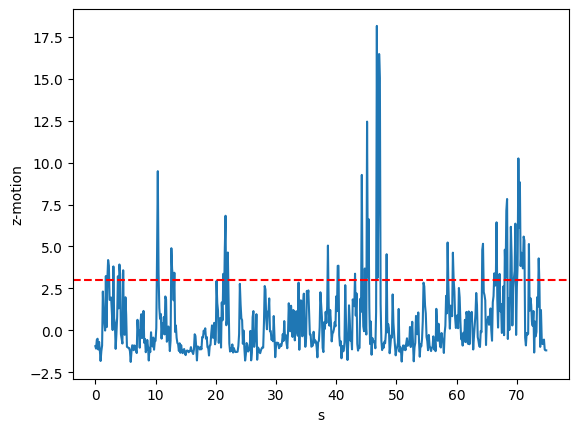

In [194]:
feats, meta = extract_video_features(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset\20160824_12males\20160830_ri3rdConditioning_males\Video2 20160830 RI_cropped_rois\mouse5804_Day03.mp4")
import matplotlib.pyplot as plt
t = np.arange(len(meta["trace_z"])) / meta["trace_hz"]
plt.plot(t[0:600], meta["trace_z"][0:600]); plt.axhline(3, color="r", ls="--")  # z=3 bout threshold
plt.xlabel("s"); plt.ylabel("z-motion"); plt.show()

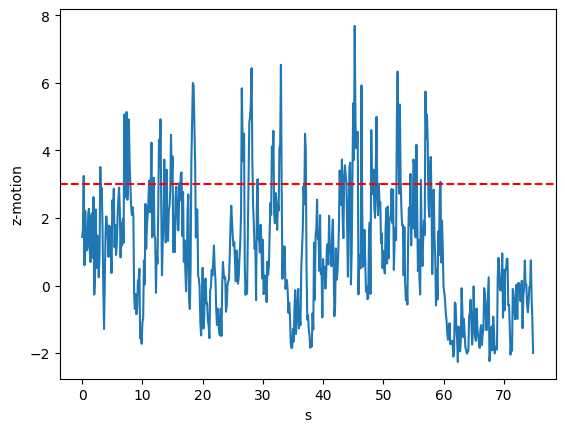

In [195]:
feats, meta = extract_video_features(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions\Maladaptive\Controls\20251110_mouse978527_trainingSessions\Day04\mouse978527_Day04_topView_comp.avi")
import matplotlib.pyplot as plt
t = np.arange(len(meta["trace_z"])) / meta["trace_hz"]
plt.plot(t[0:600], meta["trace_z"][0:600]); plt.axhline(3, color="r", ls="--")  # z=3 bout threshold
plt.xlabel("s"); plt.ylabel("z-motion"); plt.show()

# From stefanos datasets:

- If a mouse has one session "extremely highAgg" combined with another "highAgg": maladaptive. Otherwise, he is a plain aggressor
- If a mouse has 3 or more high Agg in a row: maladaptive

In [ ]:
# -----------------------------
# group definitions
# -----------------------------

# MR dataset
Agg = ["975826", "975827", "975833", "978772", "978774", "988590", "997838", "1010820", "1010823", "1010826", "1029741"]
nonAgg = ["975830", "978775", "1010819", "997839", "997840", "997841", "1029736", "1029739", "1032216"]
maladaptive = ["978513", "978527", "978528", "1010832", "1013590", "1034805", "1034814"]

saline_mice = ["978513", "978527", "978528"]
psilo_mice = ["1010832", "1013590", "1034805", "1034814"]

# Maladaptive prescreening dataset
extraMal = ["978518","1034810","1034811","1034807", "1070005", "1070008", "1070011", "1070015", "1070014", "1069997", "1069998",
            "1070013"] # Turned NonAgg after surgery or died after surgery (SHIELD)
extraAgg = ["1034819","1034820","1034821","1034822","1034823","1034804","1034806","1034815","1034818", "1070001", "1070002", 
            "1070004", "1070006", "1070007", "1070000", "1070012", "1070013"] # Keeping an eye for "1070013". Might be Mal 
extraNonAgg =["1034812", "1070003", "1070009", "1070010", "1069996"]


# Stefanos dataset
Agg_Ste = ["4901", "4902", "5111", "5112", "5281", "5282", "5812", "5813", "5801", "5802", "5671", "5672", "5761", "5762",
           "9041", "9043", "9044", "9045", "9181", "9182", "9361", "9362", "9363", "9302", "9303", "9932", "9891", 
            "9304", "9931","5281", "5282", "5112", "4902", "2323", "2324", "2325", "2326", "2327", 
           "2330", "223", "225", "227", "243", "248", "2332", "2341", "2338", "237", "218", "219", "477", "2", "4", "7", 
           "8", "9", "12", "14", "18", "19", "23", "24", "27", "28", "29", "32", "33", "34", "37", "39", "42", "43", "44", 
           "47", "48", "49", "52", "54", "58", "59"]
nonAgg_Ste = ["5811", "5803", "5804", "9212", "8932", "9913", "484", "485", "2304", "3", "13", "17", "22",
              "38", "53", "57"]
maladaptive_Ste = ["9042", "9892", "9893", "486", "2303"]

# Stefanos dataset: Videos that were not segmented due low visibility
extraAgg_Ste = ["5", "6", "10", "11", "15", "21", "25", "26", "30", "31", "35", "36", "40", "41", "45", "46", "51", "56", "60"]
extraNonAgg_Ste = ["1", "16","20", "50", "55"]



Agg = Agg + extraAgg + Agg_Ste + extraAgg_Ste
nonAgg = nonAgg + extraNonAgg + nonAgg_Ste + extraNonAgg_Ste
maladaptive = maladaptive + maladaptive_Ste + extraMal

# -----------------------------
# helper function to assign group
# -----------------------------
def assign_group_from_video_name(video_name):
    """
    Expects video names like:
    mouse975826_Day2_something.avi
    or
    mouse975826_Day15_something.avi
    """

    m = re.search(r"mouse(\d+)_Day(\d+)", video_name)

    if m is None:
        return None, None, None, None, "regex_no_match"

    mouse = m.group(1)
    day = int(m.group(2))

    if mouse in Agg:
            group = "Agg"

    elif mouse in nonAgg:
            group = "nonAgg"

    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"

    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive Psilocybin"

    elif mouse in saline_mice and day >= 15:
        group = "maladaptive Saline"

    else:
        return mouse, day, None, None, "mouse_day_not_assigned"

    mouse_group_id = f"{mouse}_{group}"

    return mouse, day, group, mouse_group_id, None

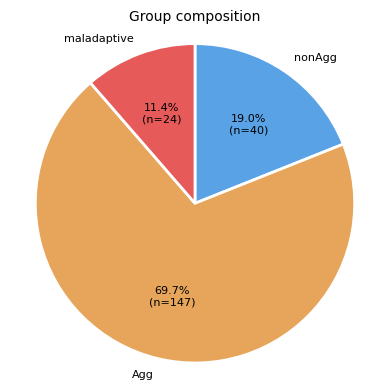

In [197]:
# Groups to plot
mal_pizza = maladaptive
agg_pizza = Agg + extraAgg_Ste
nonAgg_pizza = nonAgg + extraNonAgg_Ste

group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive": "#E65A5A"
}

# Counts
pizza_counts = {
    "nonAgg": len(nonAgg_pizza),
    "Agg": len(agg_pizza),
    "maladaptive": len(mal_pizza)
}

labels = list(pizza_counts.keys())
sizes = list(pizza_counts.values())
colors = [group_colors[label] for label in labels]

# Pizza / pie plot
plt.figure(figsize=(4, 4))

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%\n(n={int(round(pct / 100 * sum(sizes)))})",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 8}
)

plt.title("Group composition", fontsize=10)
plt.axis("equal")
plt.tight_layout()
plt.show()

In [198]:
dt_folder = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions")
ste_df_folder = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset")

video_paths = list(dt_folder.rglob("*topView_comp.avi"))
video_paths_ste = list(ste_df_folder.rglob("mouse*Day*"))

In [199]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import pandas as pd
import os
import traceback


def process_one_video_safe(item):
    """
    Safe worker that never crashes the whole pool.
    Returns features, metadata, and error information.
    """
    i, path = item

    try:
        video_name = path.stem

        mouse, day, group, mouse_group_id, reason = assign_group_from_video_name(video_name)

        features, metadata = extract_video_features(str(path))

        # Add biological / experimental metadata to features
        features["video"] = video_name
        features["video_path"] = str(path)
        features["mouse"] = mouse
        features["day"] = day
        features["group"] = group
        features["mouse_group_id"] = mouse_group_id
        features["original_index"] = i

        # Add same identifiers to technical metadata
        metadata["video"] = video_name
        metadata["video_path"] = str(path)
        metadata["mouse"] = mouse
        metadata["day"] = day
        metadata["group"] = group
        metadata["mouse_group_id"] = mouse_group_id
        metadata["reason"] = reason
        metadata["original_index"] = i

        return {
            "ok": True,
            "features": features,
            "metadata": metadata,
            "error": None,
            "path": str(path),
            "original_index": i,
        }

    except Exception as e:
        return {
            "ok": False,
            "features": None,
            "metadata": None,
            "error": repr(e),
            "traceback": traceback.format_exc(),
            "path": str(path),
            "original_index": i,
        }


all_videos = video_paths + video_paths_ste

# Start conservatively. Increase later if stable.
n_workers = 18

results = []

with ThreadPoolExecutor(max_workers=n_workers) as executor:
    futures = [
        executor.submit(process_one_video_safe, item)
        for item in enumerate(all_videos)
    ]

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing videos"):
        results.append(future.result())


# Separate successful and failed videos
successful = [r for r in results if r["ok"]]
failed = [r for r in results if not r["ok"]]

# Sort to restore original all_videos order
successful = sorted(successful, key=lambda r: r["original_index"])
failed = sorted(failed, key=lambda r: r["original_index"])

rows = [r["features"] for r in successful]
metadata_rows = [r["metadata"] for r in successful]

video_features = pd.DataFrame(rows)
video_metadata = pd.DataFrame(metadata_rows)
failed_videos = pd.DataFrame(failed)

print(f"Successfully processed: {len(successful)} / {len(all_videos)}")
print(f"Failed: {len(failed)}")

Processing videos:   0%|          | 0/774 [00:00<?, ?it/s]

Successfully processed: 774 / 774
Failed: 0


In [181]:
# smallest by total pixel area
i = video_metadata["resolution_pixels"].idxmin()
print("Smallest frame:", video_metadata.loc[i, ["video_path", "width", "height", "resolution_pixels"]].to_dict())

# the minimum width and height SEPARATELY (they may come from different videos)
print("Min width: ", video_metadata["width"].min())
print("Min height:", video_metadata["height"].min())
print("Min frame_count:", video_metadata["frame_count"].min())   # shortest video (fewest frames)
print("Min duration: ", video_metadata["duration_seconds_raw_video"].min())

Smallest frame: {'video_path': 'C:\\Users\\stagk\\OneDrive\\Desktop\\trainingAggression_MR\\trainingSessions\\Stefanos_RIdataset\\20160629_6males\\20160630_ri2ndConditioning_males\\Video 1_20160630_Male RI conditioning _cropped_rois\\mouse5281_Day02.mp4', 'width': 112, 'height': 220, 'resolution_pixels': 24640}
Min width:  112
Min height: 220
Min frame_count: 6755
Min duration:  687.3333333333334


In [ ]:
# -----------------------------
# imports
# -----------------------------
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable


# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive": "#E65A5A"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive": "^"
}

group_order = ["nonAgg", "Agg", "maladaptive"]

pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red",
    ["#5AA2E6", "#E6A55A", "#E65A5A"]
)


# -----------------------------
# prepare data
# -----------------------------

plot_df = video_features.copy()
plot_df["group"] = plot_df["group"].astype(str).str.strip()
plot_df["day"] = pd.to_numeric(plot_df["day"], errors="coerce")

# -----------------------------
# KEEP ONLY 50 fps
# -----------------------------
fps_col = next((c for c in ["fps", "native_fps", "fps_bin"]
                if c in plot_df.columns), None)
if fps_col is not None:
    plot_df["_fps"] = pd.to_numeric(plot_df[fps_col], errors="coerce").round()
    before = len(plot_df)
    plot_df = plot_df[plot_df["_fps"] == 50].copy()
    print(f"Kept {len(plot_df)} of {before} videos at 50 fps "
          f"(filtered on '{fps_col}').")
else:
    # fps not in video_features -> pull it from video_metadata, per mouse
    fcol = next((c for c in ["fps", "native_fps"] if c in video_metadata.columns), None)
    fps_by_mouse = (video_metadata.groupby("mouse")[fcol]
                    .agg(lambda s: round(s.dropna().mode().iloc[0])))
    plot_df["_fps"] = plot_df["mouse"].map(fps_by_mouse)
    before = len(plot_df)
    plot_df = plot_df[plot_df["_fps"] == 50].copy()
    print(f"Kept {len(plot_df)} of {before} videos at 50 fps "
          f"(fps mapped per-mouse from video_metadata['{fcol}']).")

# (rest of your cell unchanged: exclude psilocybin, drop day-0 baseline,
#  merge groups, collapse per mouse, MI, PCA, ...)

# clean labels
plot_df["group"] = plot_df["group"].astype(str).str.strip()

# make sure day is numeric
plot_df["day"] = pd.to_numeric(plot_df["day"], errors="coerce")

# exclude psilocybin videos
plot_df = plot_df[
    ~plot_df["group"].isin([
        "maladaptive Psilocybin",
        "maladaptive after Psilocybin"
    ])
].copy()

# remove unintended maladaptive baseline day 0 videos
# This fixes: maladaptive baseline 50 -> 35
plot_df = plot_df[
    ~(
        (plot_df["group"] == "maladaptive baseline") &
        (plot_df["day"] == 0)
    )
].copy()

# merge naive groups into parent groups
# merge maladaptive baseline + saline into one maladaptive group
plot_df["group_merged"] = plot_df["group"].replace({
    "naive Agg": "Agg",
    "naive nonAgg": "nonAgg",

    "maladaptive baseline": "maladaptive",
    "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive"
})

# keep only desired groups
plot_df = plot_df[
    plot_df["group_merged"].isin(group_order)
].copy()

print("Rows before mouse averaging:")
print(plot_df["group"].value_counts())

print("\nMerged rows before mouse averaging:")
print(plot_df["group_merged"].value_counts())


# -----------------------------
# collapse all days/videos to one row per mouse
# -----------------------------
plot_df = (
    plot_df
    .groupby(["mouse", "group_merged"], as_index=False)
    .mean(numeric_only=True)
)

group_order_present = [
    g for g in group_order
    if g in plot_df["group_merged"].unique()
]

print("\nNumber of mouse/group points used:", len(plot_df))
print(plot_df["group_merged"].value_counts())

print("\nMouse/group rows:")
print(
    plot_df[["mouse", "group_merged"]]
    .sort_values(["group_merged", "mouse"])
)


# -----------------------------
# feature selection
# -----------------------------
metadata_cols = [
    "mouse",
    "group",
    "group_merged",
    "day",
    "PC1",
    "PC2",
    "original_index"
]

metadata_cols = [c for c in metadata_cols if c in plot_df.columns]

feature_cols = [
    c for c in plot_df.columns
    if c not in metadata_cols
    and not c.startswith("raw_")   # exclude raw camera-dependent features
]

# keep numeric feature columns only
feature_cols = (
    plot_df[feature_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

X_df = plot_df[feature_cols].copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# remove constant features
valid_features = X_df.columns[X_df.std(axis=0) > 0]
X_df = X_df[valid_features]

print(f"\nNumber of valid features: {len(valid_features)}")
print("Valid features:")
print(list(valid_features))


# -----------------------------
# mutual information feature selection
# -----------------------------
y = LabelEncoder().fit_transform(plot_df["group_merged"])

X_scaled_for_mi = StandardScaler().fit_transform(X_df)

mi = mutual_info_classif(
    X_scaled_for_mi,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = max(1, len(valid_features) // 3)
top_features = mi_scores.head(top_n).index

print("\nTop MI features:")
print(mi_scores.head(top_n))


# -----------------------------
# PCA
# -----------------------------
X_selected = X_df[top_features].copy()
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

print("\nExplained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")
print(f"Total PC1 + PC2: {pca.explained_variance_ratio_[:2].sum() * 100:.1f}%")


# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(
    pca.components_[0],
    index=top_features,
    name="PC1_weight"
)

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)


# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_merged"] == g, "PC1"].values
    for g in group_order_present
]


# -----------------------------
# per-group feature contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(
    X_selected_scaled,
    columns=top_features,
    index=plot_df.index
)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_merged"].values

group_pc1_contrib = (
    pc1_contrib
    .groupby("group")
    .mean()
    .T
)

top_heat_n = top_n

top_motion_features = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_motion_features, group_order_present]


# -----------------------------
# shared color scale for loading plot and heatmap
# -----------------------------
max_abs = max(
    np.abs(top_loadings.values).max(),
    np.abs(heat.values).max()
)

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])


# -----------------------------
# output dataframe
# -----------------------------
mouse_pca_df = plot_df.copy()


Kept 264 of 774 videos at 50 fps (fps mapped per-mouse from video_metadata['fps']).
Rows before mouse averaging:
group
Agg                     101
nonAgg                   87
maladaptive baseline     35
maladaptive Saline       12
Name: count, dtype: int64

Merged rows before mouse averaging:
group_merged
Agg            101
nonAgg          87
maladaptive     47
Name: count, dtype: int64

Number of mouse/group points used: 27
group_merged
Agg            11
nonAgg          9
maladaptive     7
Name: count, dtype: int64

Mouse/group rows:
      mouse group_merged
1   1010820          Agg
2   1010823          Agg
3   1010826          Agg
8   1029741          Agg
12   975826          Agg
13   975827          Agg
15   975833          Agg
19   978772          Agg
20   978774          Agg
22   988590          Agg
23   997838          Agg
4   1010832  maladaptive
5   1013590  maladaptive
10  1034805  maladaptive
11  1034814  maladaptive
16   978513  maladaptive
17   978527  maladaptive
18   9785

In [202]:
# =====================================================================
# PC SEARCH: which components / features separate nonAgg from fighters?
# Unsupervised PCA (no labels used to build it), then test each PC.
# Assumes `plot_df` exists with a group column (group_merged / group_plot).
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu, kruskal

# --- pick the group column ---
group_col = next((c for c in ["group_plot", "group_merged", "group"]
                  if c in plot_df.columns), None)
if group_col is None:
    raise KeyError("No group column found in plot_df.")

# --- choose feature columns (exclude labels, ids, and camera/dataset metadata) ---
EXCLUDE = {
    "mouse", "group", "group_merged", "group_plot", "day", "reason",
    "video", "video_path", "dataset", "mouse_group_id", "original_index",
    "PC1", "PC2",
    # technical metadata that would act as dataset/fps proxies if left in:
    "fps", "effective_hz", "target_hz", "downsampled", "native_fps",
    "frame_count", "width", "height", "resolution_pixels", "aspect_ratio",
    "duration_seconds_raw_video", "analyzed_duration_seconds",
    "n_motion_samples", "target_pixels_internal", "resize_width_internal",
}
feature_cols = [
    c for c in plot_df.columns
    if c not in EXCLUDE and not str(c).startswith(("raw_", "qc_"))
    and pd.api.types.is_numeric_dtype(plot_df[c])
]

# --- build matrix, clean, drop constant columns ---
X_df = plot_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_df = X_df.loc[:, X_df.std(axis=0) > 0]          # remove constant features
feature_cols = X_df.columns.tolist()
X_scaled = StandardScaler().fit_transform(X_df)

print(f"N mice: {X_scaled.shape[0]}   |   features: {X_scaled.shape[1]}")
print(plot_df[group_col].value_counts().to_string())
assert np.isfinite(X_scaled).all(), "non-finite values entering PCA"

# --- unsupervised PCA with ALL components (so later PCs exist) ---
n_comp = min(X_scaled.shape)
pca = PCA(n_components=n_comp).fit(X_scaled)
Y = pca.transform(X_scaled)
for k in range(min(2, n_comp)):
    plot_df[f"PC{k+1}"] = Y[:, k]   # keep PC1/PC2 for downstream plots

# --- binary trusted contrast: nonAgg vs everything-that-fights ---
binary = np.where(plot_df[group_col].values == "nonAgg", "nonAgg", "fighter")
mask_non = binary == "nonAgg"
n_non, n_fig = mask_non.sum(), (~mask_non).sum()
print(f"\nnonAgg = {n_non}   fighter = {n_fig}")

def rank_biserial(a, b):
    """Effect size from Mann-Whitney U; |r| ~0.1 small, 0.3 med, 0.5 large."""
    U, p = mannwhitneyu(a, b, alternative="two-sided")
    r = abs(1 - 2 * U / (len(a) * len(b)))
    return p, r

def bh_fdr(pvals):
    """Benjamini-Hochberg q-values."""
    pvals = np.asarray(pvals, float)
    m = len(pvals)
    order = np.argsort(pvals)
    bh = np.minimum.accumulate((pvals[order] * m / np.arange(1, m + 1))[::-1])[::-1]
    q = np.empty(m); q[order] = np.clip(bh, 0, 1)
    return q

# --- test every PC ---
pc_rows = []
for k in range(n_comp):
    p, r = rank_biserial(Y[mask_non, k], Y[~mask_non, k])
    pc_rows.append({"PC": k + 1, "p": p, "r": r,
                    "var%": pca.explained_variance_ratio_[k] * 100})
pc_res = pd.DataFrame(pc_rows)
pc_res["q"] = bh_fdr(pc_res["p"].values)

print("\n================ PC SEARCH (nonAgg vs fighter) ================")
for _, row in pc_res.iterrows():
    flag = "  <-- SEPARATES" if row["q"] < 0.05 else ""
    print(f"PC{int(row.PC):<2d}  p={row.p:.4f}  q={row.q:.4f}  "
          f"|r|={row.r:.2f}  var={row['var%']:4.1f}%{flag}")

# --- parallel per-feature test (more direct; PCs are just mixes of these) ---
feat_rows = []
for f in feature_cols:
    p, r = rank_biserial(plot_df.loc[mask_non, f].values,
                         plot_df.loc[~mask_non, f].values)
    feat_rows.append({"feature": f, "p": p, "r": r})
feat_res = pd.DataFrame(feat_rows)
feat_res["q"] = bh_fdr(feat_res["p"].values)
feat_res = feat_res.sort_values("p").reset_index(drop=True)

print("\n================ PER-FEATURE (nonAgg vs fighter) =============")
for _, row in feat_res.iterrows():
    flag = "  <-- SEPARATES" if row["q"] < 0.05 else ""
    print(f"{row.feature:26s} p={row.p:.4f}  q={row.q:.4f}  |r|={row.r:.2f}{flag}")

# --- if a PC separates, show what loads on it ---
sig_pcs = pc_res.loc[pc_res["q"] < 0.05, "PC"].astype(int).tolist()
if sig_pcs:
    print("\n================ LOADINGS of separating PCs ==================")
    for pc in sig_pcs:
        load = pd.Series(pca.components_[pc - 1], index=feature_cols)
        load = load.reindex(load.abs().sort_values(ascending=False).index).head(6)
        print(f"\nPC{pc} top features:")
        for name, w in load.items():
            print(f"   {name:26s} {w:+.3f}")
else:
    print("\nNo PC separates nonAgg from fighter at q<0.05 — "
          "check the per-feature table and the dataset confound below.")

# --- optional 3-group test on PC1/PC2 (your original question) ---
print("\n================ 3-GROUP (Kruskal) on PC1, PC2 ===============")
for k in range(min(2, n_comp)):
    groups = [Y[plot_df[group_col].values == g, k] for g in plot_df[group_col].unique()]
    H, p = kruskal(*groups)
    print(f"PC{k+1}: H={H:.2f}  p={p:.4f}")

N mice: 123   |   features: 33
group_merged
Agg            86
nonAgg         25
maladaptive    12

nonAgg = 25   fighter = 98

================ PC SEARCH (nonAgg vs fighter) ================
PC1   p=0.0063  q=0.1043  |r|=0.36  var=49.5%
PC2   p=0.7510  q=0.8545  |r|=0.04  var=17.4%
PC3   p=0.1965  q=0.4632  |r|=0.17  var=10.4%
PC4   p=0.1583  q=0.4455  |r|=0.18  var= 5.7%
PC5   p=0.8332  q=0.8593  |r|=0.03  var= 3.7%
PC6   p=0.1003  q=0.4137  |r|=0.21  var= 3.2%
PC7   p=0.2386  q=0.5250  |r|=0.15  var= 2.4%
PC8   p=0.0372  q=0.3070  |r|=0.27  var= 1.9%
PC9   p=0.3284  q=0.5923  |r|=0.13  var= 1.6%
PC10  p=0.3161  q=0.5923  |r|=0.13  var= 1.1%
PC11  p=0.8875  q=0.8875  |r|=0.02  var= 0.7%
PC12  p=0.1620  q=0.4455  |r|=0.18  var= 0.6%
PC13  p=0.0177  q=0.1943  |r|=0.31  var= 0.4%
PC14  p=0.0834  q=0.4137  |r|=0.23  var= 0.3%
PC15  p=0.5442  q=0.7224  |r|=0.08  var= 0.3%
PC16  p=0.1154  q=0.4231  |r|=0.20  var= 0.2%
PC17  p=0.1901  q=0.4632  |r|=0.17  var= 0.1%
PC18  p=0.5910  q=0.7224  |

Most separable PCs: PC1 (q=0.104), PC30 (q=0.104)


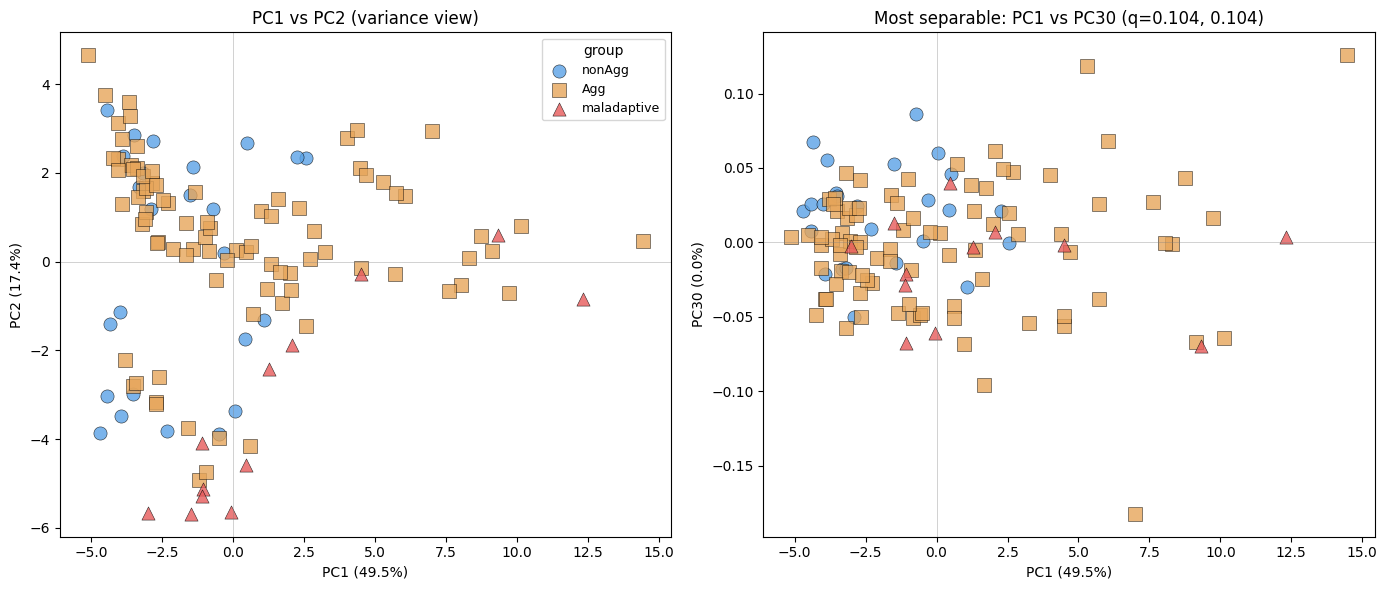

In [203]:
# pick the two most-separating PCs from cell 1's results
ranked = pc_res.sort_values("q").reset_index(drop=True)   # best (lowest q) first
best_pc_x = int(ranked.loc[0, "PC"])
best_pc_y = int(ranked.loc[1, "PC"])
print(f"Most separable PCs: PC{best_pc_x} (q={ranked.loc[0,'q']:.3f}), "
      f"PC{best_pc_y} (q={ranked.loc[1,'q']:.3f})")

import numpy as np
import matplotlib.pyplot as plt

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
group_order_present = [g for g in ["nonAgg", "Agg", "maladaptive"]
                       if g in plot_df[group_col].unique()]

# ensure every PC column we plot exists (PC1/PC2 + the two winners)
for k in {1, 2, best_pc_x, best_pc_y}:
    plot_df[f"PC{k}"] = Y[:, k - 1]

evr = pca.explained_variance_ratio_ * 100

def scatter_pcs(ax, xk, yk, title):
    for g in group_order_present:
        idx = plot_df[group_col] == g
        ax.scatter(plot_df.loc[idx, f"PC{xk}"], plot_df.loc[idx, f"PC{yk}"],
                   label=g, color=group_colors[g], marker=group_markers[g],
                   s=90, alpha=0.8, edgecolor="black", linewidth=0.4)
    ax.set_xlabel(f"PC{xk} ({evr[xk-1]:.1f}%)")
    ax.set_ylabel(f"PC{yk} ({evr[yk-1]:.1f}%)")
    ax.set_title(title)
    ax.axhline(0, color="grey", lw=0.5, alpha=0.5)
    ax.axvline(0, color="grey", lw=0.5, alpha=0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_pcs(axes[0], 1, 2, "PC1 vs PC2 (variance view)")
axes[0].legend(title="group", loc="best", fontsize=9)

scatter_pcs(axes[1], best_pc_x, best_pc_y,
            f"Most separable: PC{best_pc_x} vs PC{best_pc_y} "
            f"(q={ranked.loc[0,'q']:.3f}, {ranked.loc[1,'q']:.3f})")

plt.tight_layout()
plt.show()

Most relevant PCs this run: PC1 (q=0.104, var=49.5%), PC6 (q=0.414, var=3.2%)


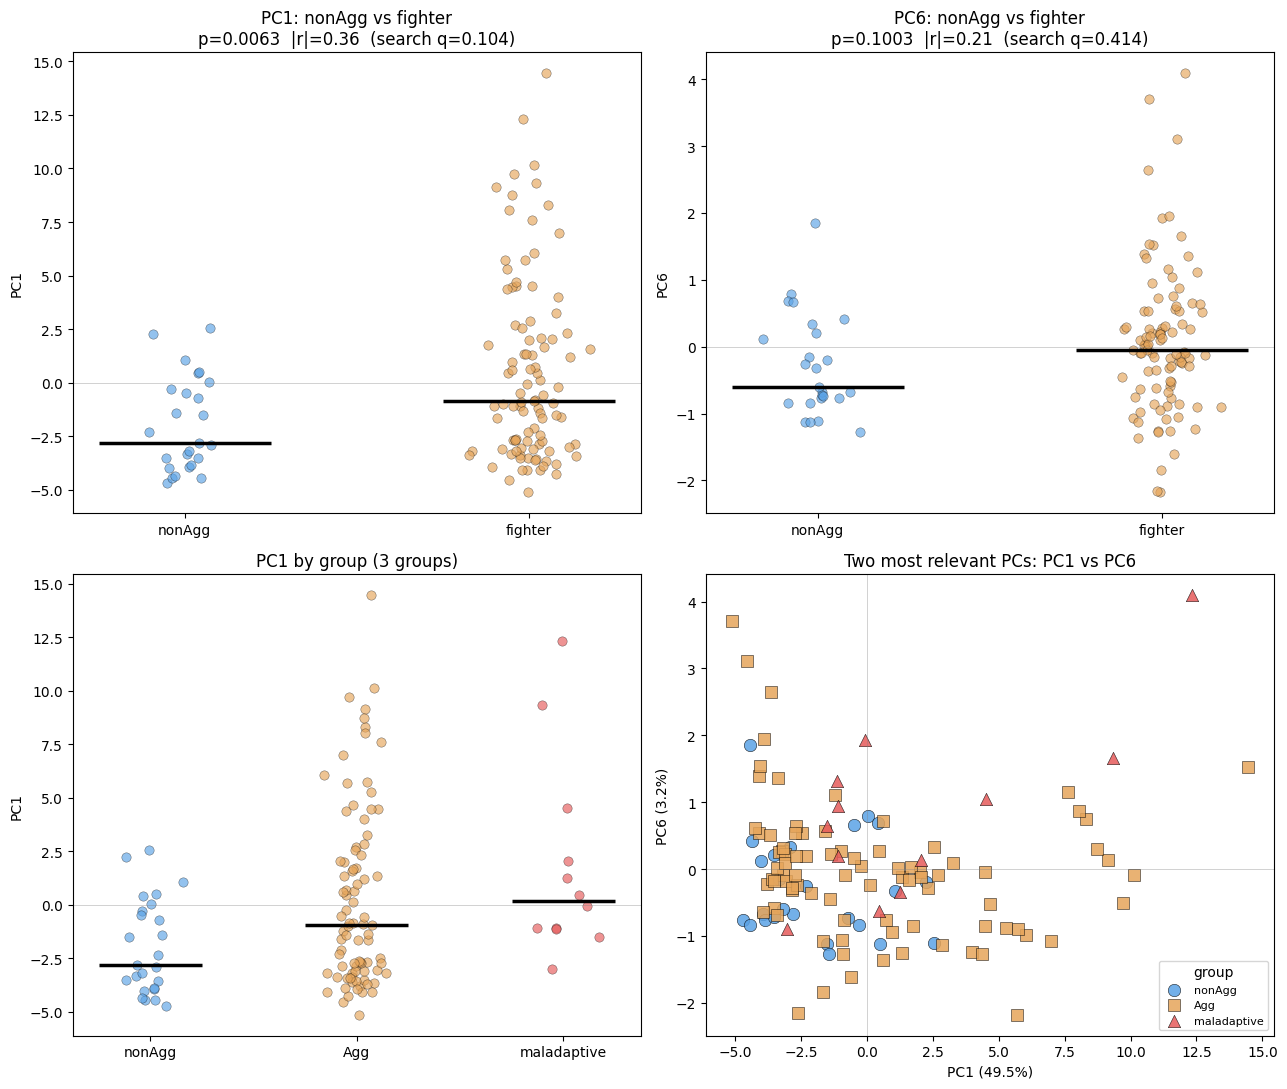

In [204]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

# =====================================================================
# Pick the 2 most relevant PCs from the search (pc_res), instead of
# hardcoding PC2. Prefer PCs that both separate (low q) AND carry real
# variance, so a 0.4%-variance noise PC can't win by chance.
# =====================================================================
MIN_VAR = 3.0  # ignore PCs explaining < this % variance when ranking

cand = pc_res[pc_res["var%"] >= MIN_VAR].sort_values("q")
if len(cand) < 2:                       # fall back if too few pass the var filter
    cand = pc_res.sort_values("q")
top2 = cand.head(2).reset_index(drop=True)
pc_a, pc_b = int(top2.loc[0, "PC"]), int(top2.loc[1, "PC"])
q_a, q_b = top2.loc[0, "q"], top2.loc[1, "q"]
print(f"Most relevant PCs this run: PC{pc_a} (q={q_a:.3f}, var={top2.loc[0,'var%']:.1f}%), "
      f"PC{pc_b} (q={q_b:.3f}, var={top2.loc[1,'var%']:.1f}%)")

# make sure the chosen PC columns exist on plot_df
for pc in (pc_a, pc_b):
    plot_df[f"PC{pc}"] = Y[:, pc - 1]

binary = np.where(plot_df[group_col].values == "nonAgg", "nonAgg", "fighter")
group_colors = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
groups3 = [g for g in ["nonAgg", "Agg", "maladaptive"] if g in plot_df[group_col].unique()]
markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}


def mw(col):
    a = plot_df.loc[binary == "nonAgg", col].values
    b = plot_df.loc[binary == "fighter", col].values
    U, p = mannwhitneyu(a, b, alternative="two-sided")
    r = abs(1 - 2 * U / (len(a) * len(b)))
    return p, r


def strip(ax, col, labels, order, colors):
    for i, g in enumerate(order):
        v = plot_df.loc[labels == g, col].values
        ax.scatter(np.random.normal(i, 0.06, len(v)), v, s=45, alpha=0.65,
                   color=colors.get(g, "#888"), edgecolor="black", linewidth=0.3)
        ax.hlines(np.median(v), i - 0.25, i + 0.25, color="black", lw=2.5, zorder=5)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    ax.set_ylabel(col); ax.axhline(0, color="grey", lw=0.5, alpha=0.5)


# =====================================================================
# Row 1: strip plot of EACH relevant PC, nonAgg vs fighter (the honest view)
# Row 2: 2D scatter of the two relevant PCs together
# =====================================================================
fig = plt.figure(figsize=(13, 11))

# --- strips for the two PCs (binary contrast, with test) ---
for j, (pc, q) in enumerate([(pc_a, q_a), (pc_b, q_b)]):
    ax = fig.add_subplot(2, 2, j + 1)
    strip(ax, f"PC{pc}", binary, ["nonAgg", "fighter"],
          {"nonAgg": "#5AA2E6", "fighter": "#E6A55A"})
    p, r = mw(f"PC{pc}")
    ax.set_title(f"PC{pc}: nonAgg vs fighter\np={p:.4f}  |r|={r:.2f}  (search q={q:.3f})")

# --- strip of best PC by all 3 groups (context) ---
ax = fig.add_subplot(2, 2, 3)
strip(ax, f"PC{pc_a}", plot_df[group_col].values, groups3, group_colors)
ax.set_title(f"PC{pc_a} by group (3 groups)")

# --- 2D scatter of the two most relevant PCs, by group ---
ax = fig.add_subplot(2, 2, 4)
evr = pca.explained_variance_ratio_ * 100
for g in groups3:
    idx = plot_df[group_col] == g
    ax.scatter(plot_df.loc[idx, f"PC{pc_a}"], plot_df.loc[idx, f"PC{pc_b}"],
               label=g, color=group_colors[g], marker=markers[g],
               s=80, alpha=0.85, edgecolor="black", linewidth=0.4)
ax.set_xlabel(f"PC{pc_a} ({evr[pc_a-1]:.1f}%)")
ax.set_ylabel(f"PC{pc_b} ({evr[pc_b-1]:.1f}%)")
ax.set_title(f"Two most relevant PCs: PC{pc_a} vs PC{pc_b}")
ax.legend(title="group", fontsize=8)
ax.axhline(0, color="grey", lw=0.5, alpha=0.5); ax.axvline(0, color="grey", lw=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

fps per mouse (batch proxy):
fps_bin
10    59
50    27
8     21
15    16
PC1 vs fps:  Kruskal H=58.54  p=1.204e-12   <-- PC tracks acquisition (CONFOUND)
PC2 vs fps:  Kruskal H=67.24  p=1.663e-14   <-- PC tracks acquisition (CONFOUND)


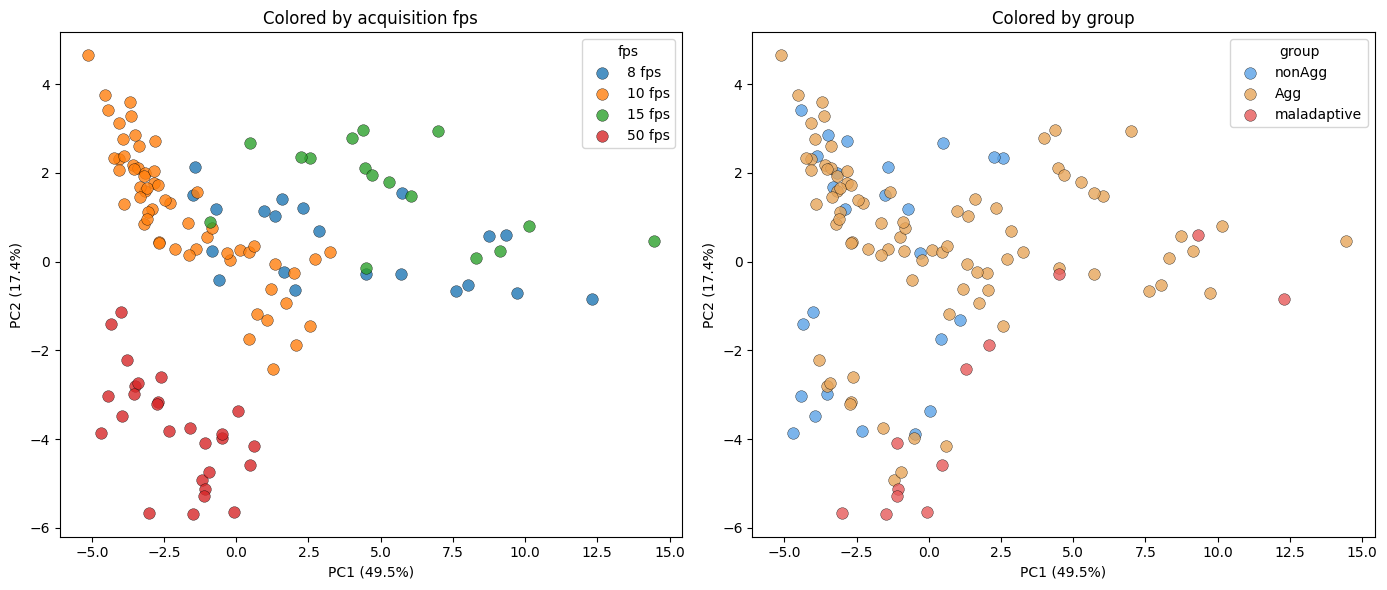

In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

group_col = next((c for c in ["group_plot", "group_merged", "group"]
                  if c in plot_df.columns), None)
group_colors = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
groups3 = [g for g in ["nonAgg", "Agg", "maladaptive"] if g in plot_df[group_col].unique()]

# ensure PC1/PC2 exist on plot_df
if "PC1" not in plot_df.columns or "PC2" not in plot_df.columns:
    plot_df["PC1"] = Y[:, 0]
    plot_df["PC2"] = Y[:, 1]

# --- build a per-mouse fps label from video_metadata ---
fpscol = next((c for c in ["fps", "native_fps"] if c in video_metadata.columns), None)
if fpscol is None or "mouse" not in video_metadata.columns:
    raise KeyError("Need an fps column + 'mouse' in video_metadata to build fps_bin.")
fps_per_mouse = (video_metadata.groupby("mouse")[fpscol]
                 .agg(lambda s: int(round(s.dropna().mode().iloc[0]))))
plot_df["fps_bin"] = plot_df["mouse"].map(fps_per_mouse)

fps_levels = sorted(plot_df["fps_bin"].dropna().unique())
print("fps per mouse (batch proxy):")
print(plot_df["fps_bin"].value_counts().to_string())

# --- does each PC track acquisition fps? (confound test) ---
for pc in ["PC1", "PC2"]:
    grps = [plot_df.loc[plot_df["fps_bin"] == f, pc].values for f in fps_levels]
    grps = [g for g in grps if len(g) > 0]
    if len(grps) >= 2:
        H, pf = kruskal(*grps)
        flag = "   <-- PC tracks acquisition (CONFOUND)" if pf < 0.05 else ""
        print(f"{pc} vs fps:  Kruskal H={H:.2f}  p={pf:.4g}{flag}")

# --- PC1 vs PC2 colored by fps (left) and by group (right) ---
evr = pca.explained_variance_ratio_ * 100
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
fps_cmap = {f: palette[i % len(palette)] for i, f in enumerate(fps_levels)}
for f in fps_levels:
    idx = plot_df["fps_bin"] == f
    ax[0].scatter(plot_df.loc[idx, "PC1"], plot_df.loc[idx, "PC2"],
                  label=f"{f} fps", color=fps_cmap[f], s=70, alpha=0.8,
                  edgecolor="black", linewidth=0.3)
ax[0].set_xlabel(f"PC1 ({evr[0]:.1f}%)"); ax[0].set_ylabel(f"PC2 ({evr[1]:.1f}%)")
ax[0].set_title("Colored by acquisition fps"); ax[0].legend(title="fps")

for g in groups3:
    idx = plot_df[group_col] == g
    ax[1].scatter(plot_df.loc[idx, "PC1"], plot_df.loc[idx, "PC2"],
                  label=g, color=group_colors[g], s=70, alpha=0.8,
                  edgecolor="black", linewidth=0.3)
ax[1].set_xlabel(f"PC1 ({evr[0]:.1f}%)"); ax[1].set_ylabel(f"PC2 ({evr[1]:.1f}%)")
ax[1].set_title("Colored by group"); ax[1].legend(title="group")

plt.tight_layout()
plt.show()

Nuisance regression uses: ['fps_bin']
Mice per group x fps:
 fps          8.0   10.0  15.0  50.0
group                              
Agg            15    47    13    11
maladaptive     3     2     0     7
nonAgg          3    10     3     9

3-group vs fps association: chi2=19.05  p=0.0041



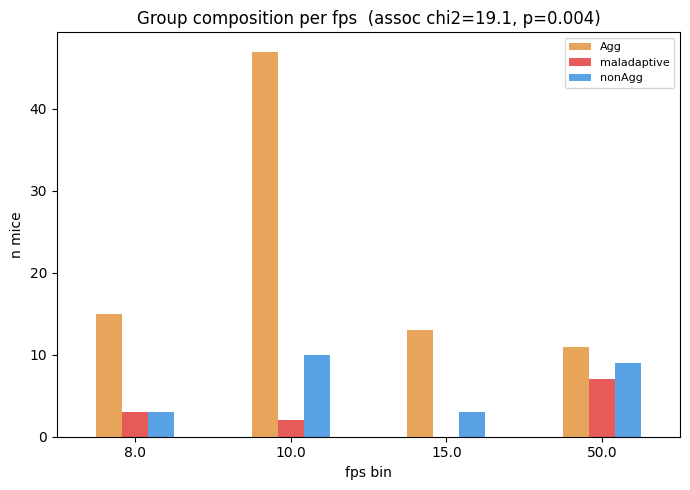

A. per-fps mean-centering: best PC1 (49.0%), second PC2 (13.1%); 3-group Kruskal-Wallis p=0.0000  eps2=0.17
B. per-fps z-scoring (center+scale): best PC1 (57.6%), second PC2 (11.0%); 3-group Kruskal-Wallis p=0.0000  eps2=0.19
C. nuisance regression (fps+res): best PC1 (49.0%), second PC2 (13.1%); 3-group Kruskal-Wallis p=0.0000  eps2=0.17


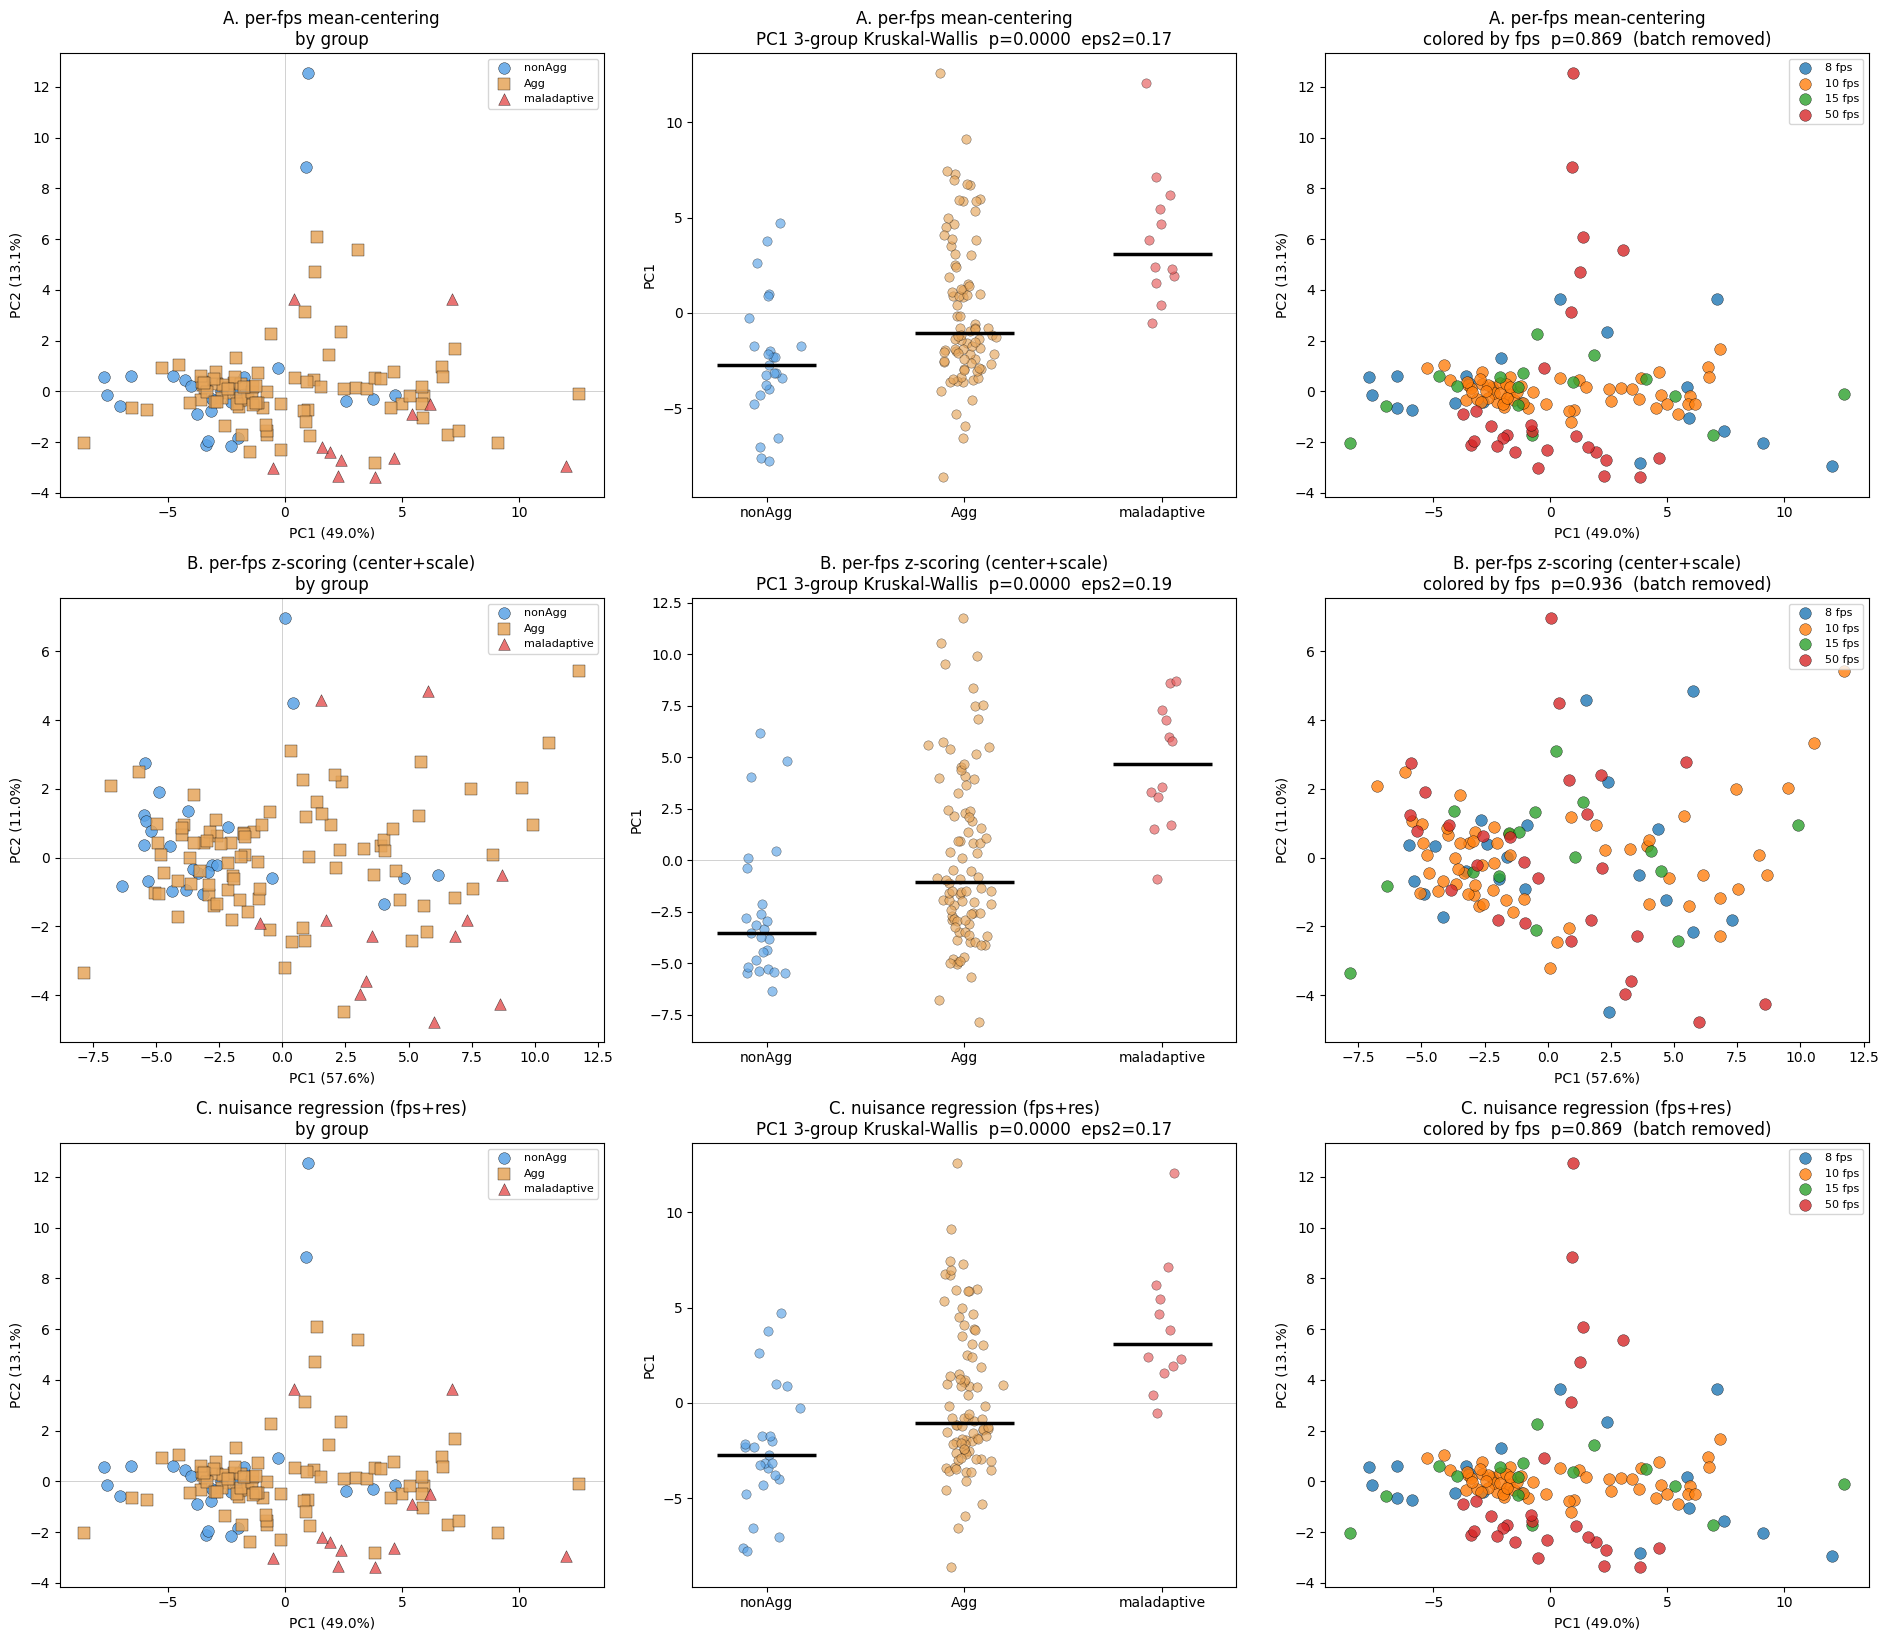


Three normalizations compared. A/B normalize WITHIN fps bins; C residualizes each feature on a fitted fps+resolution model (the method used in the classifier cell). Check the fps-colored panel: lower Kruskal p there means batch better removed. eps2 from the best PC is a search, so mildly optimistic; the generalizable number is the leak-free CV AUC.


In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# =====================================================================
# SETUP
# =====================================================================
group_col = next((c for c in ["group_plot", "group_merged", "group"]
                  if c in plot_df.columns), None)
if "fps_bin" not in plot_df.columns:
    fpscol = next((c for c in ["fps", "native_fps"] if c in video_metadata.columns), None)
    fpm = (video_metadata.groupby("mouse")[fpscol]
           .agg(lambda s: int(round(s.dropna().mode().iloc[0]))))
    plot_df["fps_bin"] = plot_df["mouse"].map(fpm)

fps_all = plot_df["fps_bin"].values
valid = ~pd.isna(fps_all)
if (~valid).sum():
    print(f"Dropping {(~valid).sum()} mice with no fps label.")

X = X_df.values.astype(float)[valid]
fps = fps_all[valid].astype(float)
grp3 = plot_df[group_col].values[valid]
fps_levels = sorted(np.unique(fps))
g3 = [g for g in ["nonAgg", "Agg", "maladaptive"] if g in np.unique(grp3)]

# ---- nuisance design matrix for the regression method (fps + resolution) ----
NUIS_CONT = [c for c in ["resolution_pixels", "width", "height"] if c in plot_df.columns]
NUIS_CAT  = [c for c in ["fps_bin"] if c in plot_df.columns]
parts = []
if NUIS_CONT:
    parts.append(plot_df.loc[valid, NUIS_CONT].astype(float).reset_index(drop=True))
if NUIS_CAT:
    parts.append(pd.get_dummies(plot_df.loc[valid, NUIS_CAT].astype(str), drop_first=True)
                 .reset_index(drop=True))
N = pd.concat(parts, axis=1).fillna(0.0).values.astype(float) if parts else None
print("Nuisance regression uses:", (NUIS_CONT + NUIS_CAT) if N is not None else "NONE")

ct3 = pd.crosstab(pd.Series(grp3, name="group"), pd.Series(fps, name="fps"))
chi2, p_assoc, _, _ = chi2_contingency(ct3.values)
print("Mice per group x fps:\n", ct3.to_string())
print(f"\n3-group vs fps association: chi2={chi2:.2f}  p={p_assoc:.4f}\n")

# =====================================================================
# THREE NORMALIZATION METHODS
#   A: per-fps mean-centering
#   B: per-fps z-scoring (center+scale)
#   C: nuisance regression (residualize features on fps+resolution)  <-- NEW
# =====================================================================
def norm_center(Xin):
    Xc = Xin.copy()
    for f in fps_levels:
        m = fps == f
        if m.sum() >= 2:
            Xc[m] -= Xc[m].mean(0)
    return Xc

def norm_zscore(Xin):
    Xc = Xin.copy()
    for f in fps_levels:
        m = fps == f
        if m.sum() >= 2:
            mu, sd = Xc[m].mean(0), Xc[m].std(0)
            sd[sd == 0] = 1.0
            Xc[m] = (Xc[m] - mu) / sd
    return Xc

def norm_regress(Xin):
    """Residualize every feature on the nuisance matrix (fps + resolution)."""
    if N is None:
        return Xin.copy()
    reg = LinearRegression().fit(N, Xin)
    return Xin - reg.predict(N)

def run_pca(Xc):
    Xs = StandardScaler().fit_transform(Xc)
    p = PCA(n_components=min(Xs.shape)).fit(Xs)
    return p.transform(Xs), p.explained_variance_ratio_ * 100

def kw3(Y, k):
    samples = [Y[grp3 == g, k] for g in g3]
    H, p = kruskal(*samples)
    n = sum(len(s) for s in samples)
    eps2 = (H - len(g3) + 1) / (n - len(g3)) if n > len(g3) else np.nan
    return p, max(eps2, 0.0)

def pick_axes(Y, evr, min_var=3.0):
    stats = [(k, *kw3(Y, k), evr[k]) for k in range(Y.shape[1])]
    cand = [s for s in stats if s[3] >= min_var]
    if len(cand) < 2:
        cand = stats
    cand = sorted(cand, key=lambda s: s[1])
    return cand[0][0], cand[1][0]

METHODS = {
    "A": ("per-fps mean-centering",           norm_center),
    "B": ("per-fps z-scoring (center+scale)", norm_zscore),
    "C": ("nuisance regression (fps+res)",    norm_regress),
}

# =====================================================================
# FIGURE 0 (separate): group composition per fps
# =====================================================================
group_colors = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
fig0, ax0 = plt.subplots(figsize=(7, 5))
ct3.T.plot(kind="bar", ax=ax0, color=[group_colors.get(g, "#888") for g in ct3.T.columns])
ax0.set_xlabel("fps bin"); ax0.set_ylabel("n mice")
ax0.set_title(f"Group composition per fps  (assoc chi2={chi2:.1f}, p={p_assoc:.3f})")
ax0.legend(fontsize=8); ax0.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

# =====================================================================
# PLOT HELPERS
# =====================================================================
markers = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
PAL = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

def lab(evr, i):
    return f"PC{i+1} ({evr[i]:.1f}%)"

def scatter_group(ax, Y, xi, yi, evr, method_name):
    for g in g3:
        idx = grp3 == g
        ax.scatter(Y[idx, xi], Y[idx, yi], label=g, color=group_colors[g],
                   marker=markers[g], s=70, alpha=0.85, edgecolor="black", linewidth=0.3)
    ax.set_xlabel(lab(evr, xi)); ax.set_ylabel(lab(evr, yi))
    ax.set_title(f"{method_name}\nby group")
    ax.legend(fontsize=8)
    ax.axhline(0, color="grey", lw=0.5, alpha=0.5); ax.axvline(0, color="grey", lw=0.5, alpha=0.5)

def strip_group(ax, Y, pi, method_name):
    for i, g in enumerate(g3):
        v = Y[grp3 == g, pi]
        ax.scatter(np.random.normal(i, 0.06, len(v)), v, s=45, alpha=0.65,
                   color=group_colors[g], edgecolor="black", linewidth=0.3)
        ax.hlines(np.median(v), i-0.25, i+0.25, color="black", lw=2.5, zorder=5)
    ax.set_xticks(range(len(g3))); ax.set_xticklabels(g3)
    p, eps2 = kw3(Y, pi)
    ax.set_ylabel(f"PC{pi+1}"); ax.axhline(0, color="grey", lw=0.5, alpha=0.5)
    ax.set_title(f"{method_name}\nPC{pi+1} 3-group Kruskal-Wallis  p={p:.4f}  eps2={eps2:.2f}")

def scatter_fps(ax, Y, xi, yi, evr, method_name):
    for i, f in enumerate(fps_levels):
        idx = fps == f
        ax.scatter(Y[idx, xi], Y[idx, yi], label=f"{int(f)} fps",
                   color=PAL[i % len(PAL)], s=70, alpha=0.8, edgecolor="black", linewidth=0.3)
    ax.set_xlabel(lab(evr, xi)); ax.set_ylabel(lab(evr, yi))
    H, pf = kruskal(*[Y[fps == f, xi] for f in fps_levels if (fps == f).sum() > 0])
    ax.set_title(f"{method_name}\ncolored by fps  p={pf:.3g}"
                 + ("  (still tracks fps)" if pf < 0.05 else "  (batch removed)"))
    ax.legend(fontsize=8)

# =====================================================================
# FIGURES: one row per method, SAME three panels each
# =====================================================================
fig, axes = plt.subplots(len(METHODS), 3, figsize=(19, 5.5 * len(METHODS)))
for row, (key, (name, fn)) in enumerate(METHODS.items()):
    Y, evr = run_pca(fn(X))
    a, b = pick_axes(Y, evr)
    title = f"{key}. {name}"
    scatter_group(axes[row, 0], Y, a, b, evr, title)
    strip_group(axes[row, 1], Y, a, title)
    scatter_fps(axes[row, 2], Y, a, b, evr, title)
    p, eps2 = kw3(Y, a)
    print(f"{title}: best PC{a+1} ({evr[a]:.1f}%), second PC{b+1} ({evr[b]:.1f}%); "
          f"3-group Kruskal-Wallis p={p:.4f}  eps2={eps2:.2f}")

plt.tight_layout(); plt.show()

print("\nThree normalizations compared. A/B normalize WITHIN fps bins; "
      "C residualizes each feature on a fitted fps+resolution model (the method "
      "used in the classifier cell). Check the fps-colored panel: lower Kruskal p "
      "there means batch better removed. eps2 from the best PC is a search, so "
      "mildly optimistic; the generalizable number is the leak-free CV AUC.")

In [ ]:
# This cell displays the NonAgg mice that have the highest PC1 score (closer to aggression range): This videos of these mice may have clues to why this is happening

# Which PC / score column to rank by, and how many to show
PC_COL = f"PC{pc_a}" if "pc_a" in dir() else None   # uses pc_a from the PCA-search cell if present
TOP_N  = 10

# locate the group column
group_col = next((c for c in ["group_plot", "group_merged", "group"]
                  if c in plot_df.columns), None)

# pick the score column: prefer the chosen relevant PC; else first PC col present
if PC_COL is None or PC_COL not in plot_df.columns:
    pc_cols = [c for c in plot_df.columns if c.startswith("PC") and c[2:].isdigit()]
    PC_COL = pc_cols[0] if pc_cols else None
if PC_COL is None:
    raise KeyError("No PC score column found on plot_df. Run the PCA cell first "
                   "so plot_df has a 'PC1'/'PC2'/... column (or set PC_COL manually).")

# nonAgg mice, ranked by that score (highest first)
nonagg = plot_df.loc[plot_df[group_col] == "nonAgg",
                     ["mouse", group_col, PC_COL]].copy()
nonagg = nonagg.sort_values(PC_COL, ascending=False).reset_index(drop=True)

print(f"Ranking nonAgg mice by {PC_COL} (highest first), n={len(nonagg)}:\n")
print(nonagg.head(TOP_N).to_string(index=False))

print(f"\nHighest-scoring nonAgg mouse: {nonagg.iloc[0]['mouse']} "
      f"({PC_COL}={nonagg.iloc[0][PC_COL]:.2f})")
print(f"nonAgg {PC_COL}: median={nonagg[PC_COL].median():.2f}, "
      f"range {nonagg[PC_COL].min():.2f} to {nonagg[PC_COL].max():.2f}")

Ranking nonAgg mice by PC2 (highest first), n=25:

  mouse group_merged      PC2
   5803       nonAgg 4.361475
     53       nonAgg 4.161493
      3       nonAgg 3.977408
     22       nonAgg 3.696220
     57       nonAgg 3.157408
   5804       nonAgg 3.093234
     38       nonAgg 2.747272
     13       nonAgg 2.539840
   5811       nonAgg 2.466233
1010819       nonAgg 1.534816

Highest-scoring nonAgg mouse: 5803 (PC2=4.36)
nonAgg PC2: median=1.40, range -3.22 to 4.36


Group column: group_merged
group_merged
Agg            86
nonAgg         25
maladaptive    12
Residualizing nuisances: ['fps_bin']

=== nonAgg vs fighter (out-of-fold) ===
ROC-AUC = 0.686   balanced acc = 0.583
Confusion matrix [rows=true 0/1, cols=pred 0/1]:
 [[83 15]
 [17  8]]

Permutation null: mean AUC=0.487, 95th pct=0.612
Permutation p = 0.0099

Top features (permutation importance, AUC drop):
burstiness_z3            0.0032
middle_z_motion          0.0029
bout_count_z3            0.0003
fraction_high_jerk       0.0002
spectral_peak_freq_hz    0.0001
spectral_entropy         0.0000
perm_entropy             0.0000
autocorr_decay_sec       0.0000
late_z_motion            0.0000
jerk_peak                0.0000
jerk_mean_abs            0.0000
escalation_slope         0.0000


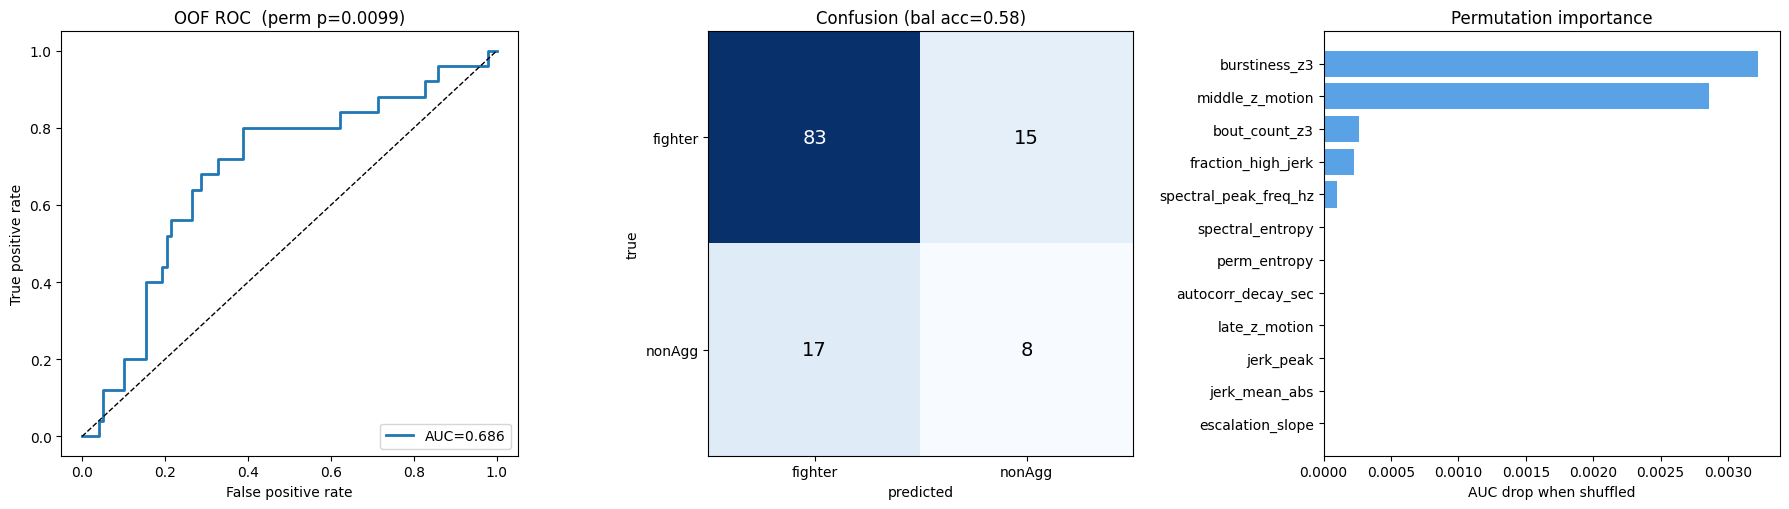


================= VERDICT =================
WEAK: above chance (p=0.0099) but AUC=0.686 < 0.75 — a real but
modest shift, not a clean separation. Report honestly as a distributional effect.


In [191]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, balanced_accuracy_score

SEED = 42
N_PERM = 100
rng = np.random.default_rng(SEED)

# ---- group column ----
group_col = next((c for c in ["group_plot", "group_merged", "group"]
                  if c in plot_df.columns), None)
if group_col is None:
    raise KeyError("No group column found in plot_df.")
print("Group column:", group_col)
print(plot_df[group_col].value_counts().to_string())

# ---- target + grouping ----
y = (plot_df[group_col].values == "nonAgg").astype(int)        # nonAgg=1, fighter=0
groups = (plot_df["mouse"].values if "mouse" in plot_df.columns
          else np.arange(len(y)))                              # animal-level CV
feature_cols = X_df.columns.tolist()
X = X_df.values.astype(float)

# ---- nuisance design matrix (fps + resolution); None if unavailable ----
NUIS_CONT = [c for c in ["resolution_pixels", "width", "height"] if c in plot_df.columns]
NUIS_CAT  = [c for c in ["fps_bin"] if c in plot_df.columns]
parts = []
if NUIS_CONT:
    parts.append(plot_df[NUIS_CONT].astype(float).reset_index(drop=True))
if NUIS_CAT:
    parts.append(pd.get_dummies(plot_df[NUIS_CAT].astype(str), drop_first=True)
                 .reset_index(drop=True))
N = pd.concat(parts, axis=1).fillna(0.0).values.astype(float) if parts else None
print("Residualizing nuisances:", NUIS_CONT + NUIS_CAT if N is not None else "NONE (no fps/res cols)")


def residualize(tr, te):
    """Fit feature~nuisance on TRAIN rows only; return residualized train/test."""
    if N is None:
        return X[tr], X[te]
    reg = LinearRegression().fit(N[tr], X[tr])
    return X[tr] - reg.predict(N[tr]), X[te] - reg.predict(N[te])


def balanced_w(yt):
    w = np.ones(len(yt), float)
    for c in (0, 1):
        m = yt == c
        if m.sum() > 0:
            w[m] = len(yt) / (2.0 * m.sum())
    return w


def model():
    return HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=300,
        l2_regularization=1.0, random_state=SEED)


def oof_auc(target):
    """Out-of-fold AUC with animal-level, stratified CV + per-fold residualization."""
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof = np.full(len(target), np.nan)
    for tr, te in cv.split(X, target, groups):
        Xtr, Xte = residualize(tr, te)
        m = model().fit(Xtr, target[tr], sample_weight=balanced_w(target[tr]))
        oof[te] = m.predict_proba(Xte)[:, 1]
    return roc_auc_score(target, oof), oof


def permute_grouped(target):
    """Shuffle labels at the GROUP (mouse) level to respect animal structure."""
    uniq = pd.unique(groups)
    glab = {g: target[groups == g][0] for g in uniq}
    shuffled = rng.permutation(list(glab.values()))
    gmap = dict(zip(uniq, shuffled))
    return np.array([gmap[g] for g in groups])


# ---- observed performance ----
obs_auc, oof = oof_auc(y)
pred = (oof >= 0.5).astype(int)
cm = confusion_matrix(y, pred)
bacc = balanced_accuracy_score(y, pred)
print(f"\n=== nonAgg vs fighter (out-of-fold) ===")
print(f"ROC-AUC = {obs_auc:.3f}   balanced acc = {bacc:.3f}")
print("Confusion matrix [rows=true 0/1, cols=pred 0/1]:\n", cm)

# ---- permutation null ----
perm = np.array([oof_auc(permute_grouped(y))[0] for _ in range(N_PERM)])
p_val = (1 + np.sum(perm >= obs_auc)) / (N_PERM + 1)
print(f"\nPermutation null: mean AUC={perm.mean():.3f}, 95th pct={np.percentile(perm,95):.3f}")
print(f"Permutation p = {p_val:.4f}")

# ---- feature importance (final model on all residualized data; interpretation) ----
if N is not None:
    reg_full = LinearRegression().fit(N, X)
    Xr_full = X - reg_full.predict(N)
else:
    Xr_full = X
final = model().fit(Xr_full, y, sample_weight=balanced_w(y))
imp = permutation_importance(final, Xr_full, y, scoring="roc_auc",
                             n_repeats=20, random_state=SEED)
imp_s = (pd.Series(imp.importances_mean, index=feature_cols)
         .sort_values(ascending=False))
print("\nTop features (permutation importance, AUC drop):")
print(imp_s.head(12).round(4).to_string())

# ---- plots ----
fig, ax = plt.subplots(1, 3, figsize=(18, 5.2))

fpr, tpr, _ = roc_curve(y, oof)
ax[0].plot(fpr, tpr, lw=2, label=f"AUC={obs_auc:.3f}")
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title(f"OOF ROC  (perm p={p_val:.4f})"); ax[0].legend(loc="lower right")

im = ax[1].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax[1].text(j, i, str(v), ha="center", va="center",
               color="white" if v > cm.max()/2 else "black", fontsize=14)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["fighter", "nonAgg"])
ax[1].set_yticks([0, 1]); ax[1].set_yticklabels(["fighter", "nonAgg"])
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
ax[1].set_title(f"Confusion (bal acc={bacc:.2f})")

top = imp_s.head(12).iloc[::-1]
ax[2].barh(top.index, top.values, color="#5AA2E6")
ax[2].set_xlabel("AUC drop when shuffled"); ax[2].set_title("Permutation importance")

plt.tight_layout(); plt.show()

# ---- verdict ----
print("\n================= VERDICT =================")
if obs_auc > 0.75 and p_val < 0.05:
    print(f"PASS: motion separates nonAgg from fighter (AUC={obs_auc:.3f}, p={p_val:.4f}).")
    print("Report this with the top features above.")
elif p_val < 0.05:
    print(f"WEAK: above chance (p={p_val:.4f}) but AUC={obs_auc:.3f} < 0.75 — a real but")
    print("modest shift, not a clean separation. Report honestly as a distributional effect.")
else:
    print(f"FAIL: AUC={obs_auc:.3f}, p={p_val:.4f}. Motion energy cannot reliably separate")
    print("even the easy contrast. This justifies moving to pose tracking.")

Full feature set        AUC = 0.710
WITHOUT fraction_z_gt_10   AUC = 0.696
ONLY    fraction_z_gt_10   AUC = 0.588
WITHOUT fraction_z_gt_10: permutation p = 0.0198 (null mean 0.493)

Leave-one-out: AUC drop when each feature is removed (top 12):
fraction_z_gt_5          0.0208
fraction_z_gt_3          0.0176
fraction_z_gt_10         0.0147
z_motion_kurtosis        0.0139
spectral_peak_freq_hz    0.0131
early_late_ratio         0.0110
ibi_cv_z3                0.0106
middle_z_motion          0.0098
z_motion_skew            0.0094
max_bout_duration_z5     0.0090
jerk_peak                0.0086
jerk_mean_abs            0.0073


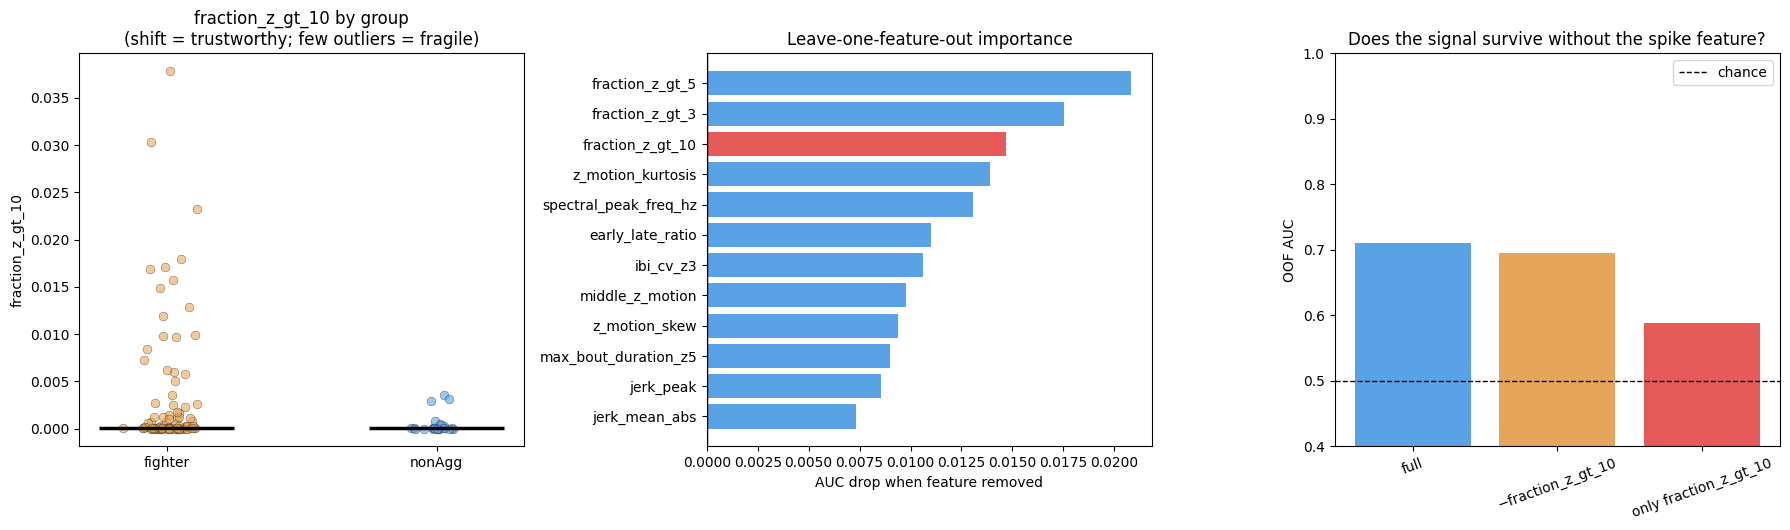


================= ROBUSTNESS VERDICT =================
ROBUST: without fraction_z_gt_10, AUC holds at 0.696. The signal is
distributed across features, not dependent on one fragile spike metric.


In [153]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)
SPIKE = "fraction_z_gt_10"   # the feature that dominated importance

# ---- rebuild context (self-contained) ----
group_col = next((c for c in ["group_plot", "group_merged", "group"]
                  if c in plot_df.columns), None)
y = (plot_df[group_col].values == "nonAgg").astype(int)
groups = plot_df["mouse"].values if "mouse" in plot_df.columns else np.arange(len(y))
feature_cols = X_df.columns.tolist()
X = X_df.values.astype(float)

NUIS_CONT = [c for c in ["resolution_pixels", "width", "height"] if c in plot_df.columns]
NUIS_CAT  = [c for c in ["fps_bin"] if c in plot_df.columns]
parts = []
if NUIS_CONT: parts.append(plot_df[NUIS_CONT].astype(float).reset_index(drop=True))
if NUIS_CAT:  parts.append(pd.get_dummies(plot_df[NUIS_CAT].astype(str), drop_first=True).reset_index(drop=True))
N = pd.concat(parts, axis=1).fillna(0.0).values.astype(float) if parts else None

def balanced_w(yt):
    w = np.ones(len(yt))
    for c in (0,1):
        m = yt==c
        if m.sum(): w[m] = len(yt)/(2.0*m.sum())
    return w

def model():
    return HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                           max_iter=300, l2_regularization=1.0,
                                           random_state=SEED)

def oof_auc(cols, target=y):
    Xs = X[:, cols]
    cv = StratifiedGroupKFold(5, shuffle=True, random_state=SEED)
    oof = np.full(len(target), np.nan)
    for tr, te in cv.split(Xs, target, groups):
        if N is not None:
            reg = LinearRegression().fit(N[tr], Xs[tr])
            Xtr, Xte = Xs[tr]-reg.predict(N[tr]), Xs[te]-reg.predict(N[te])
        else:
            Xtr, Xte = Xs[tr], Xs[te]
        m = model().fit(Xtr, target[tr], sample_weight=balanced_w(target[tr]))
        oof[te] = m.predict_proba(Xte)[:,1]
    return roc_auc_score(target, oof)

def permute_grouped(target):
    uniq = pd.unique(groups)
    glab = {g: target[groups==g][0] for g in uniq}
    gmap = dict(zip(uniq, rng.permutation(list(glab.values()))))
    return np.array([gmap[g] for g in groups])

all_idx = list(range(len(feature_cols)))
spike_idx = feature_cols.index(SPIKE) if SPIKE in feature_cols else None

# ---- headline comparisons ----
auc_full  = oof_auc(all_idx)
auc_minus = oof_auc([i for i in all_idx if i != spike_idx]) if spike_idx is not None else np.nan
auc_spike = oof_auc([spike_idx]) if spike_idx is not None else np.nan

print(f"Full feature set        AUC = {auc_full:.3f}")
print(f"WITHOUT {SPIKE:18s} AUC = {auc_minus:.3f}")
print(f"ONLY    {SPIKE:18s} AUC = {auc_spike:.3f}")

# permutation null for the minus-spike model (is the rest still above chance?)
if spike_idx is not None:
    cols_minus = [i for i in all_idx if i != spike_idx]
    perm = np.array([oof_auc(cols_minus, permute_grouped(y)) for _ in range(100)])
    p_minus = (1 + np.sum(perm >= auc_minus)) / 101
    print(f"WITHOUT {SPIKE}: permutation p = {p_minus:.4f} "
          f"(null mean {perm.mean():.3f})")

# ---- full leave-one-out: AUC with each feature removed ----
loo = {}
for j, name in enumerate(feature_cols):
    loo[name] = oof_auc([i for i in all_idx if i != j])
loo = pd.Series(loo)
delta = (auc_full - loo).sort_values(ascending=False)   # how much each feature helps
print("\nLeave-one-out: AUC drop when each feature is removed (top 12):")
print(delta.head(12).round(4).to_string())

# ---- plots ----
fig, ax = plt.subplots(1, 3, figsize=(18, 5.4))

# (a) the dominant feature by group: clean shift or outlier-driven?
if spike_idx is not None:
    binary = np.where(y == 1, "nonAgg", "fighter")
    for i, g in enumerate(["fighter", "nonAgg"]):
        v = X[binary == g, spike_idx]
        ax[0].scatter(np.random.normal(i, 0.06, len(v)), v, alpha=0.6, s=40,
                      color=["#E6A55A", "#5AA2E6"][i], edgecolor="black", linewidth=0.3)
        ax[0].hlines(np.median(v), i-0.25, i+0.25, color="black", lw=2.5, zorder=5)
    ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["fighter","nonAgg"])
    ax[0].set_ylabel(SPIKE)
    ax[0].set_title(f"{SPIKE} by group\n(shift = trustworthy; few outliers = fragile)")

# (b) leave-one-out importance
top = delta.head(12).iloc[::-1]
colors = ["#E65A5A" if n == SPIKE else "#5AA2E6" for n in top.index]
ax[1].barh(top.index, top.values, color=colors)
ax[1].axvline(0, color="black", lw=1)
ax[1].set_xlabel("AUC drop when feature removed")
ax[1].set_title("Leave-one-feature-out importance")

# (c) headline bar
labels = ["full", f"−{SPIKE}", f"only {SPIKE}"]
vals = [auc_full, auc_minus, auc_spike]
ax[2].bar(labels, vals, color=["#5AA2E6", "#E6A55A", "#E65A5A"])
ax[2].axhline(0.5, color="black", ls="--", lw=1, label="chance")
ax[2].set_ylim(0.4, 1.0); ax[2].set_ylabel("OOF AUC")
ax[2].set_title("Does the signal survive without the spike feature?")
ax[2].legend(); ax[2].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

# ---- verdict ----
print("\n================= ROBUSTNESS VERDICT =================")
if spike_idx is None:
    print(f"{SPIKE} not in features — nothing to test.")
elif auc_minus < 0.58:
    print(f"FRAGILE: without {SPIKE}, AUC collapses to {auc_minus:.3f} (~chance).")
    print("The entire result rests on ONE extreme-value feature. Treat with strong")
    print("caution — verify that feature isn't tracking artifacts, before reporting.")
elif auc_minus >= 0.65:
    print(f"ROBUST: without {SPIKE}, AUC holds at {auc_minus:.3f}. The signal is")
    print("distributed across features, not dependent on one fragile spike metric.")
else:
    print(f"PARTIAL: without {SPIKE}, AUC = {auc_minus:.3f} — some signal remains but")
    print(f"{SPIKE} carries a large share. Report the dependence honestly.")

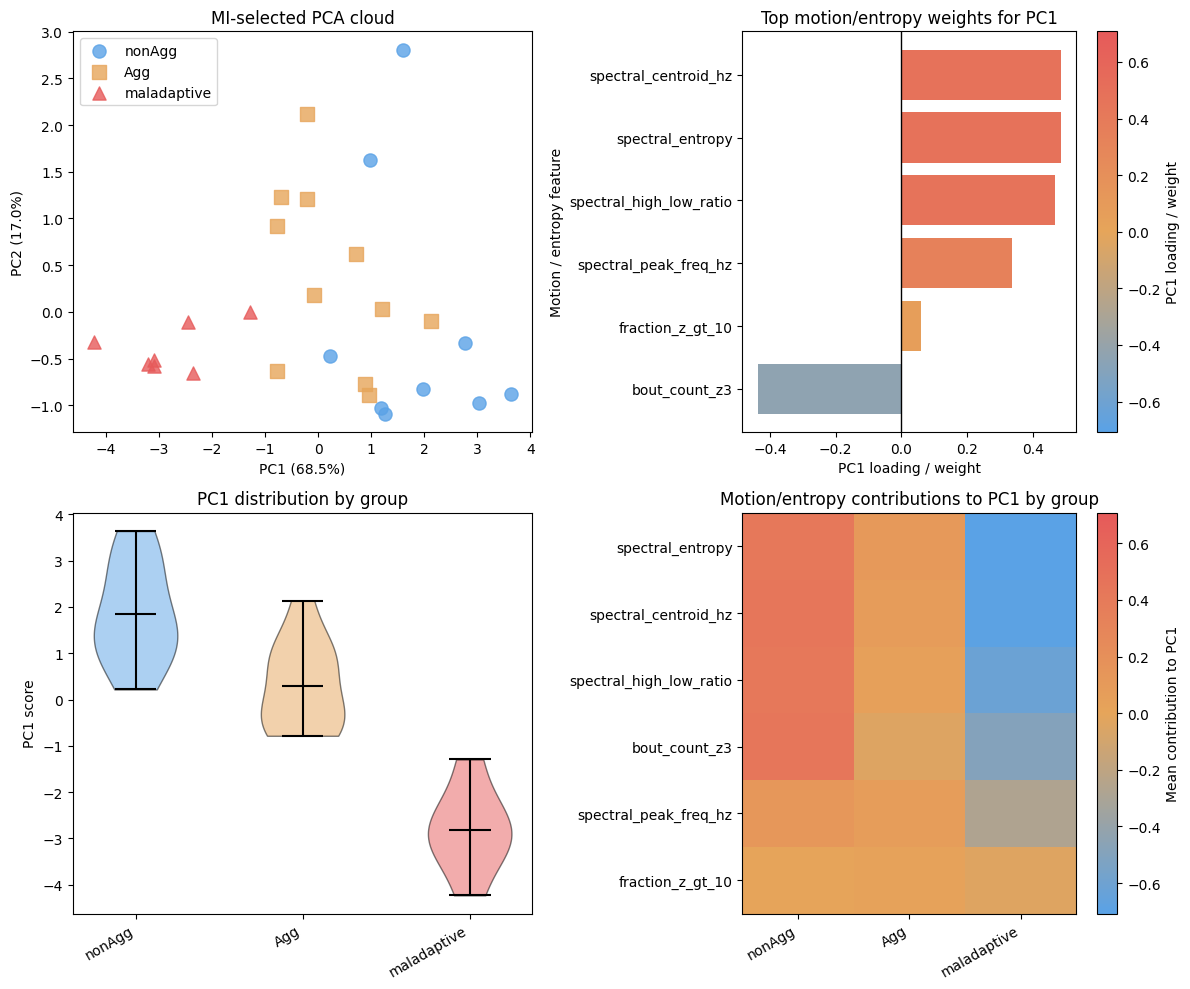

In [212]:
# -----------------------------
# imports for plotting
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# -----------------------------
# 1. PCA cloud
# -----------------------------
ax = axes[0, 0]

for g in group_order_present:
    idx = plot_df["group_merged"] == g

    ax.scatter(
        plot_df.loc[idx, "PC1"],
        plot_df.loc[idx, "PC2"],
        label=g,
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.8,
        s=90
    )

ax.legend(loc="upper left")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("MI-selected PCA cloud")

# -----------------------------
# 2. Top PC1 motion/entropy weights
# -----------------------------
ax = axes[0, 1]

bar_colors = [pc_cmap(norm(v)) for v in top_loadings.values]

ax.barh(
    top_loadings.index,
    top_loadings.values,
    color=bar_colors
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Motion / entropy feature")
ax.set_title("Top motion/entropy weights for PC1")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PC1 loading / weight")

# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]

vp = ax.violinplot(
    violin_data,
    showmeans=True,
    showmedians=False
)

for body, g in zip(vp["bodies"], group_order_present):
    body.set_facecolor(group_colors[g])
    body.set_edgecolor("black")
    body.set_alpha(0.5)

for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")

ax.set_xticks(np.arange(1, len(group_order_present) + 1))
ax.set_xticklabels(group_order_present, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")

# -----------------------------
# 4. Motion/entropy contributions to PC1 by group
# -----------------------------
ax = axes[1, 1]

im = ax.imshow(
    heat,
    aspect="auto",
    cmap=pc_cmap,
    norm=norm
)

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=30, ha="right")

ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)

ax.set_title("Motion/entropy contributions to PC1 by group")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean contribution to PC1")

plt.tight_layout()
plt.show()

Original labels retained after filtering:
group
Agg                     474
nonAgg                  165
maladaptive baseline     35
maladaptive Saline       12
Name: count, dtype: int64

Sessions/videos included after merging:
group_plot
Agg            474
nonAgg         165
maladaptive     47
Name: count, dtype: int64

Mice represented:
group_plot
Agg            90
nonAgg         26
maladaptive     7
Name: count, dtype: int64

Number of valid motion/entropy features: 20
Valid features:
['z_motion_mean', 'z_motion_std', 'z_motion_max', 'z_motion_entropy', 'fraction_z_gt_3', 'fraction_z_gt_5', 'fraction_z_gt_10', 'bout_count_z3', 'mean_bout_duration_z3', 'max_bout_duration_z3', 'bout_count_z5', 'mean_bout_duration_z5', 'max_bout_duration_z5', 'z_motion_skew', 'z_motion_kurtosis', 'early_z_motion', 'middle_z_motion', 'late_z_motion', 'early_late_ratio', 'original_index']

Top MI motion/entropy features:
original_index           0.506733
mean_bout_duration_z5    0.166767
fraction_z_gt_5  

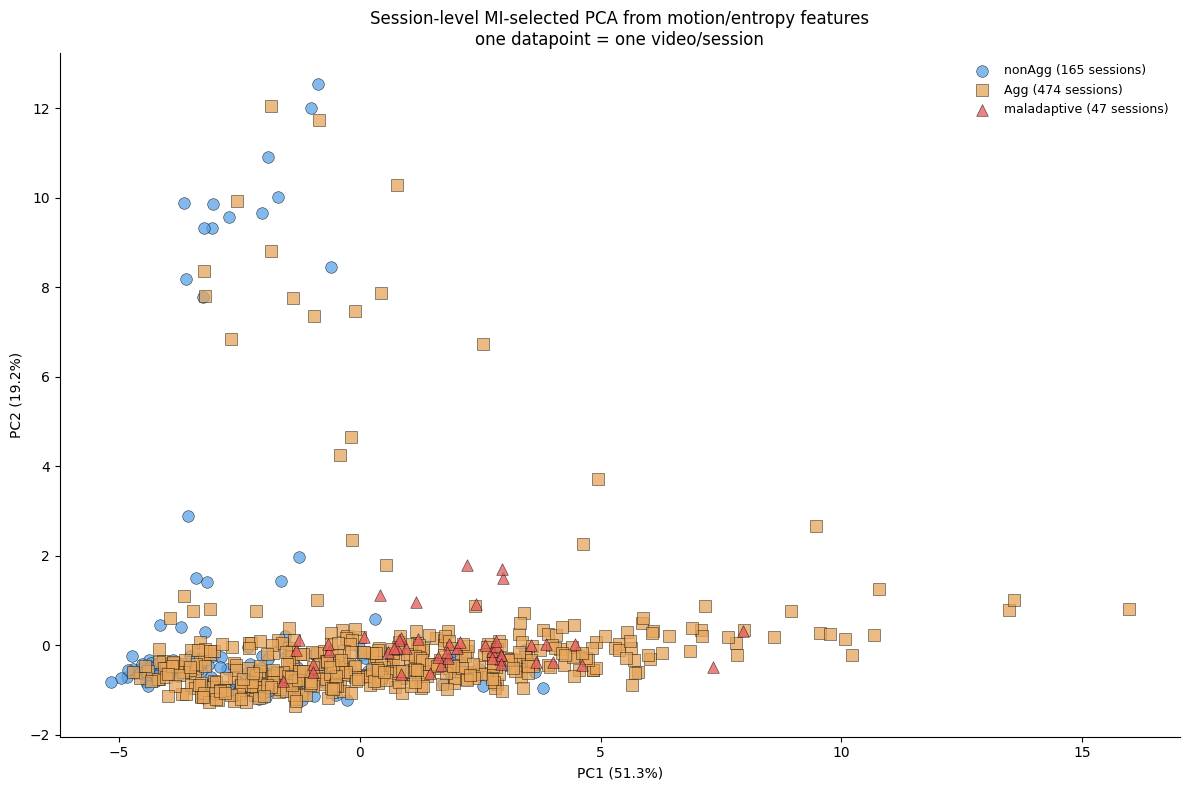

In [14]:
# -----------------------------
# imports
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA


# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive": "#E65A5A"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive": "^"
}

group_order = ["nonAgg", "Agg", "maladaptive"]


# -----------------------------
# one row = one video/session
# -----------------------------
session_video_df = video_features.copy()

# clean labels
session_video_df["group"] = session_video_df["group"].astype(str).str.strip()

# make sure day is numeric
session_video_df["day"] = pd.to_numeric(
    session_video_df["day"],
    errors="coerce"
)

# exclude psilocybin
session_video_df = session_video_df[
    ~session_video_df["group"].isin([
        "maladaptive Psilocybin",
        "maladaptive after Psilocybin"
    ])
].copy()

# remove unintended maladaptive baseline day 0 videos
# This fixes: maladaptive baseline 50 -> 35
session_video_df = session_video_df[
    ~(
        (session_video_df["group"] == "maladaptive baseline") &
        (session_video_df["day"] == 0)
    )
].copy()

# merge naive groups and maladaptive baseline/saline
session_video_df["group_plot"] = session_video_df["group"].replace({
    "naive Agg": "Agg",
    "naive nonAgg": "nonAgg",

    "maladaptive baseline": "maladaptive",
    "maladaptive Saline": "maladaptive",
    "maladaptive after Saline": "maladaptive"
})

# keep only groups of interest
session_video_df = session_video_df[
    session_video_df["group_plot"].isin(group_order)
].copy()

group_order_present = [
    g for g in group_order
    if g in session_video_df["group_plot"].unique()
]

print("Original labels retained after filtering:")
print(session_video_df["group"].value_counts())

print("\nSessions/videos included after merging:")
print(session_video_df["group_plot"].value_counts())

print("\nMice represented:")
print(
    session_video_df
    .drop_duplicates(["mouse", "group_plot"])
    ["group_plot"]
    .value_counts()
)


# -----------------------------
# feature selection
# -----------------------------
metadata_cols = [
    "video",
    "video_path",
    "mouse",
    "day",
    "group",
    "group_plot",
    "mouse_group_id",
    "PC1",
    "PC2"
]

metadata_cols = [c for c in metadata_cols if c in session_video_df.columns]

feature_cols = [
    c for c in session_video_df.columns
    if c not in metadata_cols
    and not c.startswith("raw_")   # exclude camera-dependent raw motion features
]

# keep numeric motion/entropy features only
feature_cols = (
    session_video_df[feature_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

X_df = session_video_df[feature_cols].copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# remove constant features
valid_features = X_df.columns[X_df.std(axis=0) > 0]
X_df = X_df[valid_features]

print(f"\nNumber of valid motion/entropy features: {len(valid_features)}")
print("Valid features:")
print(list(valid_features))


# -----------------------------
# mutual information feature selection
# -----------------------------
y = LabelEncoder().fit_transform(session_video_df["group_plot"])

X_scaled_for_mi = StandardScaler().fit_transform(X_df)

mi = mutual_info_classif(
    X_scaled_for_mi,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = max(2, int(len(valid_features) / 1))
top_features = mi_scores.head(top_n).index

print("\nTop MI motion/entropy features:")
print(mi_scores.head(top_n))


# -----------------------------
# PCA
# -----------------------------
X_selected = X_df[top_features].copy()
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

session_video_df["PC1"] = Y[:, 0]
session_video_df["PC2"] = Y[:, 1]

print("\nExplained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")
print(f"Total PC1 + PC2: {pca.explained_variance_ratio_[:2].sum() * 100:.1f}%")


# -----------------------------
# plot: one point per video/session
# -----------------------------
plt.figure(figsize=(12, 8))

for g in group_order_present:
    idx = session_video_df["group_plot"] == g

    plt.scatter(
        session_video_df.loc[idx, "PC1"],
        session_video_df.loc[idx, "PC2"],
        label=f"{g} ({idx.sum()} sessions)",
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.75,
        s=70,
        edgecolor="black",
        linewidth=0.4
    )

plt.legend(frameon=False, fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title(
    "Session-level MI-selected PCA from motion/entropy features\n"
    "one datapoint = one video/session"
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# -----------------------------
# optional output dataframe
# -----------------------------
session_video_pca_df = session_video_df.copy()

In [43]:
# -----------------------------
# imports
# -----------------------------
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable


# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive baseline": "#E65A5A",
    "maladaptive Saline": "#22B24D",
    "maladaptive Psilocybin": "#8A2BE2"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive baseline": "^",
    "maladaptive Saline": "D",
    "maladaptive Psilocybin": "P"
}

group_order = [
    "nonAgg",
    "Agg",
    "maladaptive baseline",
    "maladaptive Saline",
    "maladaptive Psilocybin"
]

pc_cmap = LinearSegmentedColormap.from_list(
    "blue_orange_red",
    ["#5AA2E6", "#E6A55A", "#E65A5A"]
)


# -----------------------------
# prepare data
# -----------------------------
plot_df = video_features.copy()

# clean labels
plot_df["group"] = plot_df["group"].astype(str).str.strip()

# make sure day is numeric
plot_df["day"] = pd.to_numeric(plot_df["day"], errors="coerce")

# remove unintended maladaptive baseline day 0 videos
# This fixes: maladaptive baseline 50 -> 35
plot_df = plot_df[
    ~(
        (plot_df["group"] == "maladaptive baseline") &
        (plot_df["day"] == 0)
    )
].copy()

# keep groups separate
# standardize possible "after" labels
plot_df["group_plot"] = plot_df["group"].replace({
    "naive Agg": "Agg",
    "naive nonAgg": "nonAgg",

    "maladaptive after Saline": "maladaptive Saline",
    "maladaptive after Psilocybin": "maladaptive Psilocybin"
})

# keep only desired groups
plot_df = plot_df[
    plot_df["group_plot"].isin(group_order)
].copy()

print("Rows before mouse averaging:")
print(plot_df["group"].value_counts())

print("\nGroups after label standardization, before mouse averaging:")
print(plot_df["group_plot"].value_counts())


# -----------------------------
# collapse all videos/sessions to one row per mouse per group
# -----------------------------
# This means:
# - one point per nonAgg mouse
# - one point per Agg mouse
# - one point per maladaptive baseline mouse
# - one point per maladaptive Saline mouse
# - one point per maladaptive Psilocybin mouse
plot_df = (
    plot_df
    .groupby(["mouse", "group_plot"], as_index=False)
    .mean(numeric_only=True)
)

group_order_present = [
    g for g in group_order
    if g in plot_df["group_plot"].unique()
]

print("\nNumber of mouse/group points used:", len(plot_df))
print(plot_df["group_plot"].value_counts())

print("\nMouse/group rows:")
print(
    plot_df[["mouse", "group_plot"]]
    .sort_values(["group_plot", "mouse"])
)


# -----------------------------
# feature selection
# -----------------------------
metadata_cols = [
    "mouse",
    "group",
    "group_plot",
    "group_merged",
    "day",
    "PC1",
    "PC2"
]

metadata_cols = [c for c in metadata_cols if c in plot_df.columns]

feature_cols = [
    c for c in plot_df.columns
    if c not in metadata_cols
    and not c.startswith("raw_")   # exclude raw camera-dependent features
]

# keep numeric feature columns only
feature_cols = (
    plot_df[feature_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

X_df = plot_df[feature_cols].copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# remove constant features
valid_features = X_df.columns[X_df.std(axis=0) > 0]
X_df = X_df[valid_features]

print(f"\nNumber of valid features: {len(valid_features)}")
print("Valid features:")
print(list(valid_features))


# -----------------------------
# mutual information feature selection
# -----------------------------
y = LabelEncoder().fit_transform(plot_df["group_plot"])

X_scaled_for_mi = StandardScaler().fit_transform(X_df)

mi = mutual_info_classif(
    X_scaled_for_mi,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = max(2, int(len(valid_features) / 3))
top_features = mi_scores.head(top_n).index

print("\nTop MI features:")
print(mi_scores.head(top_n))


# -----------------------------
# PCA
# -----------------------------
X_selected = X_df[top_features].copy()
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

plot_df["PC1"] = Y[:, 0]
plot_df["PC2"] = Y[:, 1]

print("\nExplained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")
print(f"Total PC1 + PC2: {pca.explained_variance_ratio_[:2].sum() * 100:.1f}%")


# -----------------------------
# PC1 loadings
# -----------------------------
pc1_weights = pd.Series(
    pca.components_[0],
    index=top_features,
    name="PC1_weight"
)

top_loadings = (
    pc1_weights
    .reindex(pc1_weights.abs().sort_values(ascending=False).head(20).index)
    .sort_values()
)


# -----------------------------
# PC1 distribution data
# -----------------------------
violin_data = [
    plot_df.loc[plot_df["group_plot"] == g, "PC1"].values
    for g in group_order_present
]


# -----------------------------
# per-group feature contribution to PC1
# -----------------------------
X_selected_df = pd.DataFrame(
    X_selected_scaled,
    columns=top_features,
    index=plot_df.index
)

pc1_contrib = X_selected_df.mul(pc1_weights, axis=1)
pc1_contrib["group"] = plot_df["group_plot"].values

group_pc1_contrib = (
    pc1_contrib
    .groupby("group")
    .mean()
    .T
)

top_heat_n = top_n

top_motion_features = (
    group_pc1_contrib.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(top_heat_n)
    .index
)

heat = group_pc1_contrib.loc[top_motion_features, group_order_present]


# -----------------------------
# shared color scale for loading plot and heatmap
# -----------------------------
max_abs = max(
    np.abs(top_loadings.values).max(),
    np.abs(heat.values).max()
)

norm = Normalize(vmin=-max_abs, vmax=max_abs)
sm = ScalarMappable(norm=norm, cmap=pc_cmap)
sm.set_array([])


# -----------------------------
# output dataframe
# -----------------------------
mouse_pca_df = plot_df.copy()

Rows before mouse averaging:
group
Agg                       90
nonAgg                    78
maladaptive baseline      35
maladaptive Psilocybin    14
maladaptive Saline        12
naive Agg                 11
naive nonAgg               9
Name: count, dtype: int64

Groups after label standardization, before mouse averaging:
group_plot
Agg                       101
nonAgg                     87
maladaptive baseline       35
maladaptive Psilocybin     14
maladaptive Saline         12
Name: count, dtype: int64

Number of mouse/group points used: 34
group_plot
Agg                       11
nonAgg                     9
maladaptive baseline       7
maladaptive Psilocybin     4
maladaptive Saline         3
Name: count, dtype: int64

Mouse/group rows:
      mouse              group_plot
1   1010820                     Agg
2   1010823                     Agg
3   1010826                     Agg
10  1029741                     Agg
16   975826                     Agg
17   975827                     

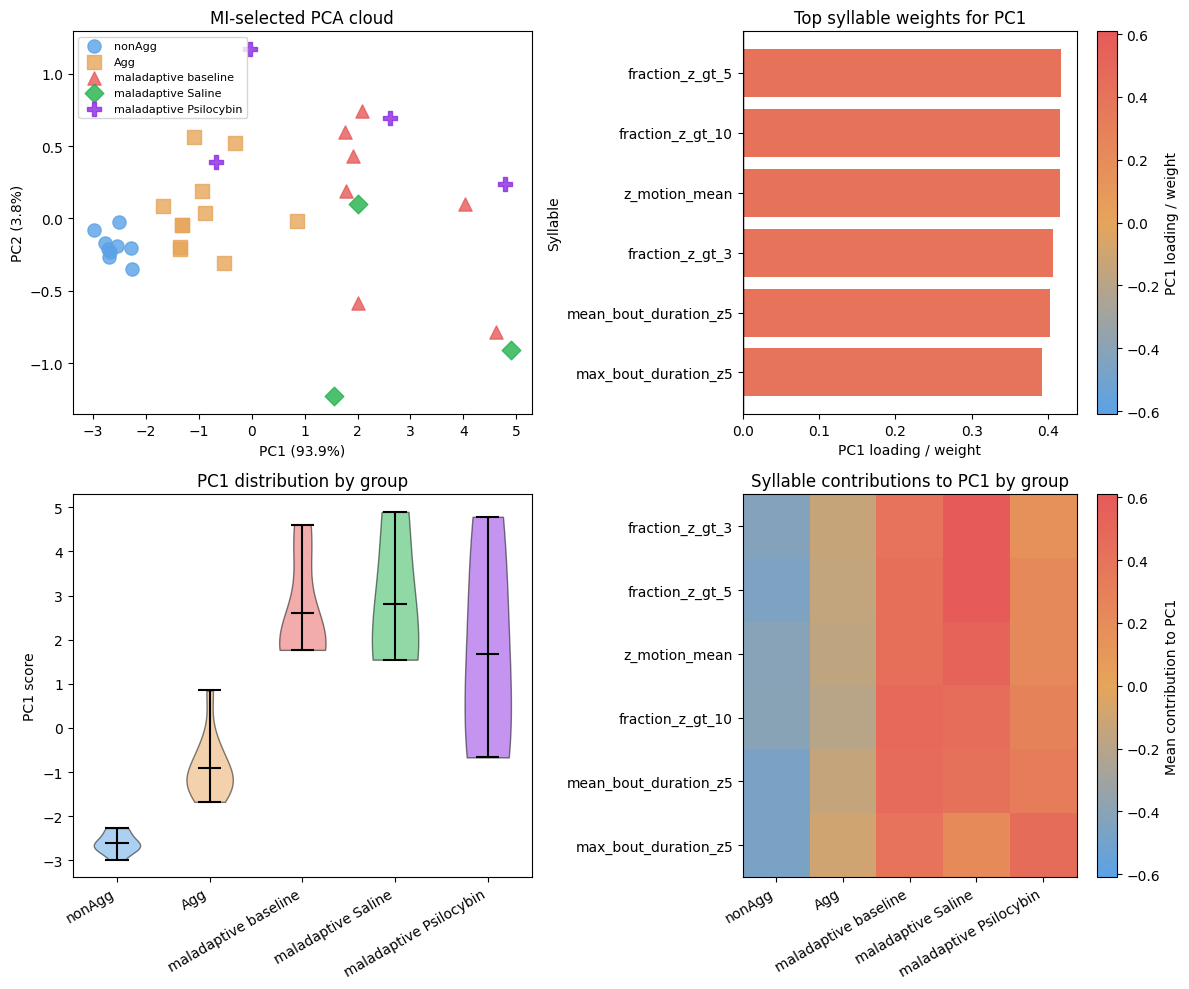

In [44]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# -----------------------------
# groups present in the current dataframe
# -----------------------------
group_order_present = [
    g for g in group_order
    if g in plot_df["group_plot"].unique()
]

violin_data = [
    plot_df.loc[plot_df["group_plot"] == g, "PC1"].values
    for g in group_order_present
]

heat_plot = heat[group_order_present]

# -----------------------------
# 1. PCA cloud
# -----------------------------
ax = axes[0, 0]

for g in group_order_present:
    idx = plot_df["group_plot"] == g

    ax.scatter(
        plot_df.loc[idx, "PC1"],
        plot_df.loc[idx, "PC2"],
        label=g,
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.8,
        s=90
    )

ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title("MI-selected PCA cloud")

# -----------------------------
# 2. Top PC1 syllable weights
# -----------------------------
ax = axes[0, 1]

bar_colors = [pc_cmap(norm(v)) for v in top_loadings.values]

ax.barh(
    top_loadings.index,
    top_loadings.values,
    color=bar_colors
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("PC1 loading / weight")
ax.set_ylabel("Syllable")
ax.set_title("Top syllable weights for PC1")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("PC1 loading / weight")

# -----------------------------
# 3. PC1 violin plot by group
# -----------------------------
ax = axes[1, 0]

vp = ax.violinplot(
    violin_data,
    showmeans=True,
    showmedians=False
)

for body, g in zip(vp["bodies"], group_order_present):
    body.set_facecolor(group_colors[g])
    body.set_edgecolor("black")
    body.set_alpha(0.5)

for key in ["cmeans", "cbars", "cmins", "cmaxes"]:
    vp[key].set_color("black")

ax.set_xticks(np.arange(1, len(group_order_present) + 1))
ax.set_xticklabels(group_order_present, rotation=30, ha="right")
ax.set_ylabel("PC1 score")
ax.set_title("PC1 distribution by group")

# -----------------------------
# 4. Syllable contributions to PC1 by group
# -----------------------------
ax = axes[1, 1]

im = ax.imshow(
    heat_plot,
    aspect="auto",
    cmap=pc_cmap,
    norm=norm
)

ax.set_xticks(np.arange(len(heat_plot.columns)))
ax.set_xticklabels(heat_plot.columns, rotation=30, ha="right")

ax.set_yticks(np.arange(len(heat_plot.index)))
ax.set_yticklabels(heat_plot.index)

ax.set_title("Syllable contributions to PC1 by group")

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean contribution to PC1")

plt.tight_layout()
plt.show()

Original labels retained after filtering:
group
Agg                       90
nonAgg                    78
maladaptive baseline      35
maladaptive Psilocybin    14
maladaptive Saline        12
naive Agg                 11
naive nonAgg               9
Name: count, dtype: int64

Sessions/videos included after label standardization:
group_plot
Agg                       101
nonAgg                     87
maladaptive baseline       35
maladaptive Psilocybin     14
maladaptive Saline         12
Name: count, dtype: int64

Mice represented:
group_plot
Agg                       11
nonAgg                     9
maladaptive baseline       7
maladaptive Psilocybin     4
maladaptive Saline         3
Name: count, dtype: int64

Number of valid motion/entropy features: 19
Valid features:
['z_motion_mean', 'z_motion_std', 'z_motion_max', 'z_motion_entropy', 'fraction_z_gt_3', 'fraction_z_gt_5', 'fraction_z_gt_10', 'bout_count_z3', 'mean_bout_duration_z3', 'max_bout_duration_z3', 'bout_count_z5', 'mean_bo

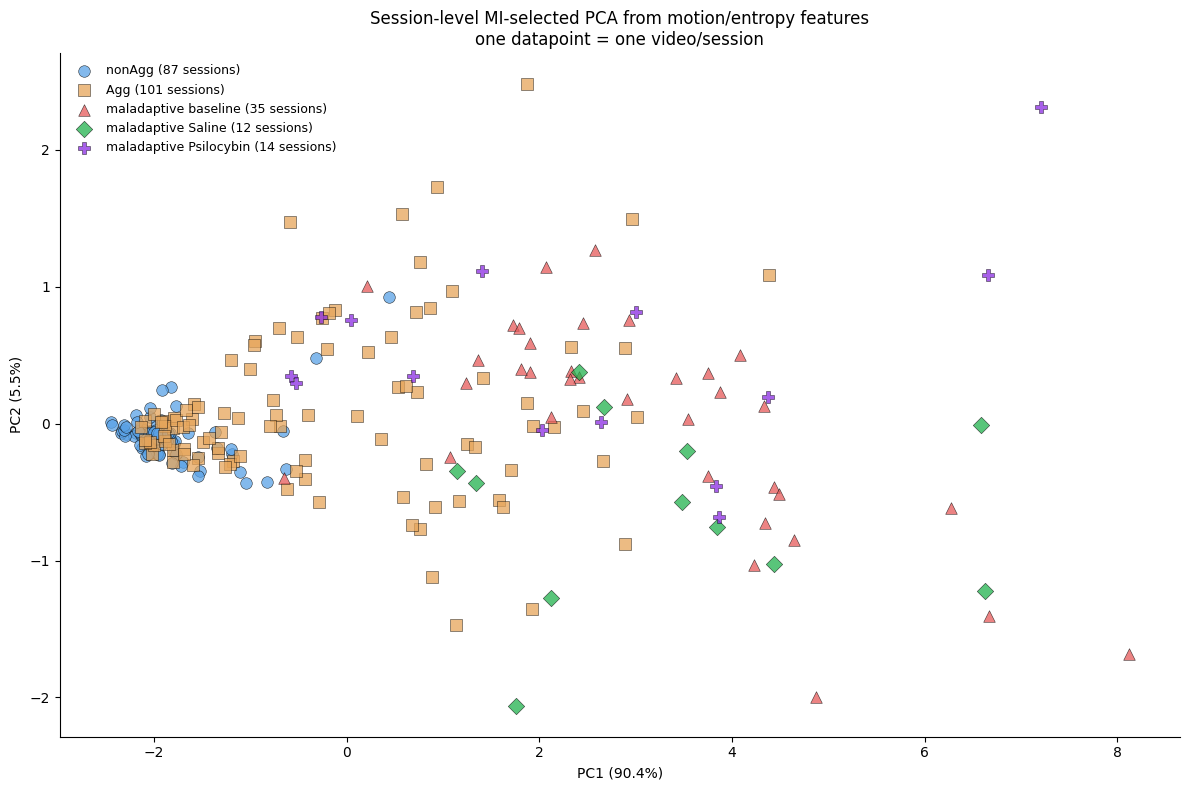

In [45]:
# -----------------------------
# imports
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA


# -----------------------------
# settings
# -----------------------------
group_colors = {
    "nonAgg": "#5AA2E6",
    "Agg": "#E6A55A",
    "maladaptive baseline": "#E65A5A",
    "maladaptive Saline": "#22B24D",
    "maladaptive Psilocybin": "#8A2BE2"
}

group_markers = {
    "nonAgg": "o",
    "Agg": "s",
    "maladaptive baseline": "^",
    "maladaptive Saline": "D",
    "maladaptive Psilocybin": "P"
}

group_order = [
    "nonAgg",
    "Agg",
    "maladaptive baseline",
    "maladaptive Saline",
    "maladaptive Psilocybin"
]


# -----------------------------
# one row = one video/session
# -----------------------------
session_video_df = video_features.copy()

# clean labels
session_video_df["group"] = session_video_df["group"].astype(str).str.strip()

# make sure day is numeric
session_video_df["day"] = pd.to_numeric(
    session_video_df["day"],
    errors="coerce"
)

# remove unintended maladaptive baseline day 0 videos
# This fixes maladaptive baseline 50 -> 35
session_video_df = session_video_df[
    ~(
        (session_video_df["group"] == "maladaptive baseline") &
        (session_video_df["day"] == 0)
    )
].copy()

# keep groups separate
# standardize possible "after" labels
session_video_df["group_plot"] = session_video_df["group"].replace({
    "naive Agg": "Agg",
    "naive nonAgg": "nonAgg",

    "maladaptive after Saline": "maladaptive Saline",
    "maladaptive after Psilocybin": "maladaptive Psilocybin"
})

# keep only the 5 groups of interest
session_video_df = session_video_df[
    session_video_df["group_plot"].isin(group_order)
].copy()

group_order_present = [
    g for g in group_order
    if g in session_video_df["group_plot"].unique()
]

print("Original labels retained after filtering:")
print(session_video_df["group"].value_counts())

print("\nSessions/videos included after label standardization:")
print(session_video_df["group_plot"].value_counts())

print("\nMice represented:")
print(
    session_video_df
    .drop_duplicates(["mouse", "group_plot"])
    ["group_plot"]
    .value_counts()
)


# -----------------------------
# feature selection
# -----------------------------
metadata_cols = [
    "video",
    "video_path",
    "mouse",
    "day",
    "group",
    "group_plot",
    "mouse_group_id",
    "PC1",
    "PC2"
]

metadata_cols = [c for c in metadata_cols if c in session_video_df.columns]

feature_cols = [
    c for c in session_video_df.columns
    if c not in metadata_cols
    and not c.startswith("raw_")   # exclude camera-dependent raw motion features
]

# keep numeric motion/entropy features only
feature_cols = (
    session_video_df[feature_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

X_df = session_video_df[feature_cols].copy()
X_df = X_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# remove constant features
valid_features = X_df.columns[X_df.std(axis=0) > 0]
X_df = X_df[valid_features]

print(f"\nNumber of valid motion/entropy features: {len(valid_features)}")
print("Valid features:")
print(list(valid_features))


# -----------------------------
# mutual information feature selection
# -----------------------------
y = LabelEncoder().fit_transform(session_video_df["group_plot"])

X_scaled_for_mi = StandardScaler().fit_transform(X_df)

mi = mutual_info_classif(
    X_scaled_for_mi,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi,
    index=X_df.columns
).sort_values(ascending=False)

top_n = max(2, int(len(valid_features) / 3))
top_features = mi_scores.head(top_n).index

print("\nTop MI motion/entropy features:")
print(mi_scores.head(top_n))


# -----------------------------
# PCA
# -----------------------------
X_selected = X_df[top_features].copy()
X_selected_scaled = StandardScaler().fit_transform(X_selected)

pca = PCA(n_components=2)
Y = pca.fit_transform(X_selected_scaled)

session_video_df["PC1"] = Y[:, 0]
session_video_df["PC2"] = Y[:, 1]

print("\nExplained variance:")
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.1f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")
print(f"Total PC1 + PC2: {pca.explained_variance_ratio_[:2].sum() * 100:.1f}%")


# -----------------------------
# plot: one point per video/session
# -----------------------------
plt.figure(figsize=(12, 8))

for g in group_order_present:
    idx = session_video_df["group_plot"] == g
    n_sessions = idx.sum()

    plt.scatter(
        session_video_df.loc[idx, "PC1"],
        session_video_df.loc[idx, "PC2"],
        label=f"{g} ({n_sessions} sessions)",
        color=group_colors[g],
        marker=group_markers[g],
        alpha=0.75,
        s=70,
        edgecolor="black",
        linewidth=0.4
    )

plt.legend(frameon=False, fontsize=9)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title(
    "Session-level MI-selected PCA from motion/entropy features\n"
    "one datapoint = one video/session"
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# -----------------------------
# output dataframe
# -----------------------------
session_video_pca_df = session_video_df.copy()

Found 264 dt + 510 ste = 774 candidate videos

Parser outcomes over all candidate paths:
ASSIGNED                  717
mouse_day_not_assigned     55
regex_no_match              2

63 videos at ~8 fps with usable labels
videos per group:
 group
Agg                     45
maladaptive baseline     9
nonAgg                   9

mice per group:
 group
Agg                     15
maladaptive baseline     3
nonAgg                   3
  extracted 25/63
  extracted 50/63

Extracted features for 63 videos.

21 mice after collapsing sessions:
group_merged
Agg            15
nonAgg          3
maladaptive     3

MI-selected top 11 of 33 motion features:
z_motion_skew, spectral_peak_freq_hz, mean_bout_duration_z3, autocorr_decay_sec, z_motion_std, max_bout_duration_z5, mean_bout_duration_z5, fraction_z_gt_5, z_motion_mean, max_bout_duration_z3, fraction_z_gt_3
PC1=77.5%  PC2=9.4%


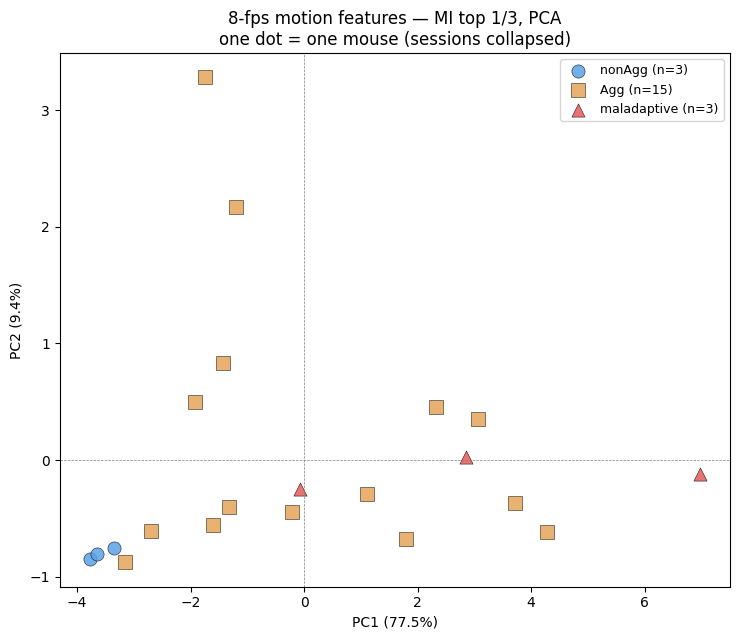

In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

# extract_video_features / get_video_metadata / FEATURE_NAMES come from the
# pipeline module already imported in the notebook.

TARGET_FPS = 8        # keep videos at this frame rate
FPS_TOL    = 1.0         # |fps - TARGET_FPS| <= FPS_TOL counts as a match
K_FRAC     = 3           # MI keeps top 1/K_FRAC features

# =====================================================================
# GROUP DEFINITIONS (mouse-ID membership lists)
# =====================================================================
# MR dataset
Agg = ["975826","975827","975833","978772","978774","988590","997838","1010820","1010823","1010826","1029741"]
nonAgg = ["975830","978775","1010819","997839","997840","997841","1029736","1029739","1032216"]
maladaptive = ["978513","978527","978528","1010832","1013590","1034805","1034814"]

saline_mice = ["978513","978527","978528"]
psilo_mice  = ["1010832","1013590","1034805","1034814"]

# Maladaptive prescreening dataset
extraMal = ["978518","1034810","1034811","1034807","1070005","1070008","1070011","1070015","1070014",
            "1069997","1069998","1070013"]
extraAgg = ["1034819","1034820","1034821","1034822","1034823","1034804","1034806","1034815","1034818",
            "1070001","1070002","1070004","1070006","1070007","1070000","1070012","1070013"]
extraNonAgg = ["1034812","1070003","1070009","1070010","1069996"]

# Stefanos dataset
Agg_Ste = ["4901","4902","5111","5112","5281","5282","5812","5813","5801","5802","5671","5672","5761","5762",
           "9041","9043","9044","9045","9181","9182","9361","9362","9363","9302","9303","9932","9891","9304","9931",
           "2323","2324","2325","2326","2327","2330","223","225","227","243","248","2332","2341","2338","237","218","219",
           "477","2","4","7","8","9","12","14","18","19","23","24","27","28","29","32","33","34","37","39","42","43","44",
           "47","48","49","52","54","58","59", 
           "2304","22", "17", "13"]
nonAgg_Ste = ["5811","5803","5804","9212","8932","9913","484","485","3","38","53","57"]
maladaptive_Ste = ["9042","9892","9893","486","2303"]
extraAgg_Ste = ["5","6","10","11","15","21","25","26","30","31","35","36","40","41","45","46","51","56","60"]
extraNonAgg_Ste = ["1","16","20","50","55"]

# merge all sources; dedupe to be safe
Agg         = sorted(set(Agg + extraAgg + Agg_Ste + extraAgg_Ste))
nonAgg      = sorted(set(nonAgg + extraNonAgg + nonAgg_Ste + extraNonAgg_Ste))
maladaptive = sorted(set(maladaptive + maladaptive_Ste + extraMal))

# integrity check: no mouse should be in more than one base group
overlap = (set(Agg) & set(nonAgg)) | (set(Agg) & set(maladaptive)) | (set(nonAgg) & set(maladaptive))
if overlap:
    print(f"WARNING: {len(overlap)} mouse IDs appear in multiple groups: {sorted(overlap)}")

# =====================================================================
# LABELLER: group depends on mouse ID AND day
# =====================================================================
def assign_group_from_video_name(video_name):
    m = re.search(r"mouse(\d+)_Day(\d+)", video_name)
    if m is None:
        return None, None, None, "regex_no_match"
    mouse = m.group(1)
    day = int(m.group(2))
    if mouse in Agg:
        group = "Agg"
    elif mouse in nonAgg:
        group = "nonAgg"
    elif mouse in maladaptive and day <= 5:
        group = "maladaptive baseline"
    elif mouse in psilo_mice and day >= 15:
        group = "maladaptive Psilocybin"
    elif mouse in saline_mice and day >= 15:
        group = "maladaptive Saline"
    else:
        return mouse, day, None, "mouse_day_not_assigned"
    return mouse, day, group, None

def parse_labels(path: Path):
    mouse, day, group, err = assign_group_from_video_name(path.name)
    return {"mouse": mouse, "day": day, "group": group, "err": err}

# =====================================================================
# COLLECT PATHS
# =====================================================================
dt_folder  = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\trainingSessions")
ste_folder = Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\Stefanos_RIdataset")
video_paths     = list(dt_folder.rglob("*topView_comp.avi"))
video_paths_ste = list(ste_folder.rglob("mouse*Day*"))
all_paths = video_paths + video_paths_ste
print(f"Found {len(video_paths)} dt + {len(video_paths_ste)} ste = {len(all_paths)} candidate videos")

# diagnostic: parser outcomes BEFORE touching any video
outcomes = [ (assign_group_from_video_name(p.name)[3] or "ASSIGNED") for p in all_paths ]
print("\nParser outcomes over all candidate paths:")
print(pd.Series(outcomes).value_counts().to_string())
if outcomes.count("ASSIGNED") == 0:
    raise SystemExit("No paths matched 'mouse###_Day##'. Check filenames; the dt "
                     "videos may not contain that pattern in their NAME.")

# =====================================================================
# 1. probe fps (header only, fast), keep TARGET_FPS, attach labels
# =====================================================================
rows = []
for p in all_paths:
    lab = parse_labels(p)
    if lab["group"] is None:                     # unparseable / not assigned
        continue
    try:
        meta = get_video_metadata(p)
    except Exception as e:
        print(f"skip (meta fail) {p.name}: {e}")
        continue
    if abs(meta["fps"] - TARGET_FPS) > FPS_TOL:  # wrong fps
        continue
    rows.append({**lab, "video_path": str(p), "fps": meta["fps"]})

vid = pd.DataFrame(rows)
print(f"\n{len(vid)} videos at ~{TARGET_FPS} fps with usable labels")
if len(vid) == 0:
    raise SystemExit("No videos at TARGET_FPS with labels. Check TARGET_FPS / FPS_TOL.")
print("videos per group:\n", vid["group"].value_counts().to_string())
print("\nmice per group:\n", vid.groupby("group")["mouse"].nunique().to_string())

# =====================================================================
# 2. extract motion features (DECODES each kept video)
# =====================================================================
feat_rows = []
for i, r in vid.reset_index(drop=True).iterrows():
    try:
        feats, _ = extract_video_features(r["video_path"])
    except Exception as e:
        print(f"skip (extract fail) {Path(r['video_path']).name}: {e}")
        continue
    feat_rows.append({**feats, "mouse": r["mouse"], "group": r["group"], "day": r["day"]})
    if (i + 1) % 25 == 0:
        print(f"  extracted {i+1}/{len(vid)}")
fdf = pd.DataFrame(feat_rows)
print(f"\nExtracted features for {len(fdf)} videos.")

# merge into 3 classes
fdf["group_merged"] = fdf["group"].replace({
    "maladaptive baseline": "maladaptive",
    "maladaptive Saline": "maladaptive",
    "maladaptive Psilocybin": "maladaptive"})
fdf = fdf[fdf["group_merged"].isin(["nonAgg", "Agg", "maladaptive"])].copy()

# =====================================================================
# 3. collapse to ONE ROW PER MOUSE (sessions averaged)
# =====================================================================
feat_cols = [c for c in FEATURE_NAMES if c in fdf.columns]
permouse = fdf.groupby(["mouse", "group_merged"], as_index=False)[feat_cols].mean()
print(f"\n{len(permouse)} mice after collapsing sessions:")
print(permouse["group_merged"].value_counts().to_string())

X = permouse[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
keep = X.std(0) > 0
X = X[:, keep]
kept_cols = np.array(feat_cols)[keep]
y = LabelEncoder().fit_transform(permouse["group_merged"].values)

# =====================================================================
# 4. MI top 1/K_FRAC (per-mouse) then 5. PCA
# =====================================================================
Xs = StandardScaler().fit_transform(X)
mi = mutual_info_classif(Xs, y, random_state=42)
k = max(1, len(kept_cols) // K_FRAC)
top_idx = np.argsort(mi)[::-1][:k]
top_cols = kept_cols[top_idx]
print(f"\nMI-selected top {k} of {len(kept_cols)} motion features:")
print(", ".join(top_cols))

Xsel = StandardScaler().fit_transform(X[:, top_idx])
pca = PCA(n_components=2).fit(Xsel)
Y = pca.transform(Xsel)
permouse["PC1"], permouse["PC2"] = Y[:, 0], Y[:, 1]
evr = pca.explained_variance_ratio_ * 100
print(f"PC1={evr[0]:.1f}%  PC2={evr[1]:.1f}%")

# =====================================================================
# 6. PC1 vs PC2 cloud — one dot per mouse
# =====================================================================
gcol = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
gmark = {"nonAgg": "o", "Agg": "s", "maladaptive": "^"}
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for g in ["nonAgg", "Agg", "maladaptive"]:
    m = permouse["group_merged"] == g
    ax.scatter(permouse.loc[m, "PC1"], permouse.loc[m, "PC2"],
               c=gcol[g], marker=gmark[g], s=90, alpha=0.85,
               edgecolor="black", linewidth=0.4, label=f"{g} (n={int(m.sum())})")
ax.axhline(0, color="grey", lw=0.5, ls="--"); ax.axvline(0, color="grey", lw=0.5, ls="--")
ax.set_xlabel(f"PC1 ({evr[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({evr[1]:.1f}%)")
ax.set_title(f"{int(round(TARGET_FPS))}-fps motion features — MI top 1/{K_FRAC}, PCA\n"
             "one dot = one mouse (sessions collapsed)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

mouse_pca_df = permouse.copy()

In [227]:
# uses `mouse_pca_df` produced by the pipeline cell (has mouse, group_merged, PC1, PC2)
non = mouse_pca_df[mouse_pca_df["group_merged"] == "nonAgg"].copy()
non = non.sort_values("PC1", ascending=False)

print(f"nonAgg mice: {len(non)} total. Top 5 by PC1 (highest first):\n")
print(non[["mouse", "group_merged", "PC1", "PC2"]].head(10).round(3).to_string(index=False))

print(f"\nnonAgg PC1 summary: median={non['PC1'].median():.3f}, "
      f"range {non['PC1'].min():.3f} to {non['PC1'].max():.3f}")

nonAgg mice: 3 total. Top 5 by PC1 (highest first):

mouse group_merged    PC1   PC2
 5804       nonAgg -2.730 0.127
 5811       nonAgg -3.294 0.349
 5803       nonAgg -3.873 0.363

nonAgg PC1 summary: median=-3.294, range -3.873 to -2.730


In [228]:
# uses `mouse_pca_df` produced by the pipeline cell (has mouse, group_merged, PC1, PC2)
non = mouse_pca_df[mouse_pca_df["group_merged"] == "Agg"].copy()
non = non.sort_values("PC1", ascending=True)

print(f"Agg mice: {len(non)} total. Top 5 by PC1 (highest first):\n")
print(non[["mouse", "group_merged", "PC1", "PC2"]].head(10).round(3).to_string(index=False))

print(f"\nAgg PC1 summary: median={non['PC1'].median():.3f}, "
      f"range {non['PC1'].min():.3f} to {non['PC1'].max():.3f}")

Agg mice: 13 total. Top 5 by PC1 (highest first):

mouse group_merged    PC1    PC2
 4901          Agg -3.722 -1.499
 5671          Agg -1.932  0.565
 5802          Agg -1.290  0.498
 5672          Agg -1.098  0.269
 5761          Agg -0.874  0.745
 5801          Agg -0.791  0.081
 4902          Agg -0.094 -1.291
 5762          Agg  0.306  1.118
 5812          Agg  0.322 -0.180
 5112          Agg  2.408 -0.661

Agg PC1 summary: median=-0.094, range -3.722 to 7.755
